### 🛠️ **Libraries**




In [1]:
import os
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import cv2
import skimage as ski
from PIL import Image, ImageDraw
from io import BytesIO

from pathlib import Path

import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch
from matplotlib.colors import to_hex
import matplotlib.patches as mpatches
import matplotlib
import plotly

from sklearn.decomposition import PCA
from sklearn.metrics import auc
from sklearn.preprocessing import StandardScaler
import sklearn as skl

import warnings
from tqdm.auto import tqdm

from scipy.cluster.hierarchy import linkage, leaves_list, fcluster,dendrogram
from scipy.stats import gaussian_kde
from scipy import ndimage

import seaborn as sns

import umap.umap_ as umap

from google.colab import drive
drive.mount('/content/gdrive')
path="/content/gdrive/MyDrive/these/"


Mounted at /content/gdrive


In [2]:
%pip install pacmap
from pacmap import PaCMAP
import pacmap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=551515 sha256=5adb244322a2febe6f48afa24a578af7d64a3094c30cbe62f3a8ac07642374ad
  Stored in directory: /root/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


### 📂 **Creating the folders**
⚠️ USER INPUT REQUIRED

In [110]:

bool_exist=False
while bool_exist==False:
 path = "/content/gdrive/MyDrive/"
 name_path = input("Enter the path where the project will be created (if the folder is in 'MyDrive' just press 'Enter'): ")
 name_project=input("Enter the name of your project: ")
 path += name_path+"/pipeline/"+ name_project+"/"
 bool_exist=os.path.isdir(path)
 if bool_exist==False:
   print("❌ The path does not exist")
 else:
  print("✅ Project :"+path)
  bool_exist=True

path_img_raw=path+"images/raw/"
path_mask_cell=path+"segmentation/segmentation_cells/mask/"
path_clust=path+"clustering/"
path_clust_mfi=path_clust+"MFI/"
path_segmentation_df=path+"segmentation/segmentation_cells/df_ROI/"
path_main_clust=path_clust+"main_clustering/"

if os.path.isdir(path_img_raw)==False:
   print("❌ You have not completed the step of creating PNG images")
elif os.path.isdir(path_mask_cell)==False:
   print("❌ You have not completed the step of cells segmentation")
elif os.path.isdir(path_clust_mfi)==False:
   print("❌ You have not completed the step of calcul of MFI")
elif os.path.isdir(path_main_clust)==False:
   print("❌ You have not completed the step of clustering the main phenotypes")
algo=input("Enter the algorithm used for segmentation: ")
path_mask_cell=path+"segmentation/segmentation_cells/mask_filtered/"+algo

pheno=input("Enter the phenotype from which you want to determine the subpopulations: ")
path_subpop=path_clust+pheno+"/"
if os.path.isdir(path_subpop)==False:
  os.mkdir(path_subpop)
  print(f"✅ The files concerning the clustering of {pheno} subpopulations can be found in the following folder:  {path_subpop}")


Enter the path where the project will be created (if the folder is in 'MyDrive' just press 'Enter'): these
Enter the name of your project: Appendix
✅ Project :/content/gdrive/MyDrive/these/pipeline/Appendix/
Enter the algorithm used for segmentation: mesmer
Enter the phenotype from which you want to determine the subpopulations: LT4


### ⚙️ **Selection of markers used to define the subpopulations**
⚠️ USER INPUT REQUIRED  
*Selection of useful markers to define subpopulations of the phenotype we wish to study*
⚠️ USER INPUT REQUIRED

#### Function

In [4]:
def choose_markers(list_marker_all, title_text="🧬 Select markers"):
    title = widgets.HTML(f"<h3>{title_text}</h3>")

    marker_selector = widgets.SelectMultiple(
        options=list_marker_all,
        description="Markers:",
        rows=min(18, len(list_marker_all)),
        layout=widgets.Layout(width="520px", height="300px")
    )

    confirm_btn = widgets.Button(description="✅ Confirm", button_style="success")
    out = widgets.Output()

    state = {"list_marker": []}

    def on_confirm(_):
        state["list_marker"] = [m.strip() for m in marker_selector.value if str(m).strip()]
        with out:
            out.clear_output(wait=True)
            print("✔ Selected markers:", state["list_marker"])

    confirm_btn.on_click(on_confirm)

    display(title, marker_selector, confirm_btn, out)
    return state



#### Execution

In [56]:
df_pheno=pd.read_csv(path_clust+"main_clustering/mfi_pheno.csv")
df_mfi_tot=pd.read_csv(path_clust+"mfi_corrected_arcsinh_std.csv")
df_num=df_mfi_tot.drop(["area","centroid-0","centroid-1","ROI","Cell_ID","label"],axis=1)
list_marker_all=df_num.columns.tolist()
state = choose_markers(list_marker_all)
list_marker = state["list_marker"]

HTML(value='<h3>🧬 Select markers</h3>')

SelectMultiple(description='Markers:', layout=Layout(height='300px', width='520px'), options=('CD163', 'CD20',…

Button(button_style='success', description='✅ Confirm', style=ButtonStyle())

Output()

In [57]:
list_marker = state["list_marker"]
df_subpop=df_mfi_tot.copy()
df_subpop=df_subpop[list_marker]
df_subpop["phenotype"]=df_pheno["phenotype"]
df_subpop["ROI"]=df_pheno["ROI"]
df_subpop["label"]=df_pheno["label"]
df_subpop=df_subpop.loc[(df_subpop.loc[:,"phenotype"]==pheno)]
df_subpop=df_subpop.drop(["phenotype"],axis=1)
df_subpop.to_csv(path_subpop+"mfi_"+pheno+"_subpop.csv",index=False)
print(f"✅ The dataframe with all the {pheno} cells and the markers used to define the subpopulations can be found there:  {path_subpop+"mfi_"+pheno+"_subpop.csv"}")
df_subpop_num=df_subpop.drop(["ROI","label"],axis=1)
print(df_subpop.shape)
df_subpop.columns

✅ The dataframe with all the LT4 cells and the markers used to define the subpopulations can be found there:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/mfi_LT4_subpop.csv
(16759, 5)


Index(['FOXP3', 'HLADR', 'PD1', 'ROI', 'label'], dtype='object')

### 📊 **Visualization of the markers among the phenotype**
*Overview of Mfi distribution for selected markers in the phenotype*


In [63]:
df_subpop_num=pd.read_csv(path_subpop+"mfi_"+pheno+"_subpop.csv")
df_subpop_num=df_subpop_num.drop(["label","ROI"],axis=1)
df_subpop_num.head()

,FOXP3,HLADR,PD1
0,2.138132,3.062035,1.497794
1,-0.378150,-0.685014,2.432714
2,-0.287683,-1.348972,-0.240394
3,0.068727,-0.936490,0.409420
4,0.441679,-0.485195,0.128908


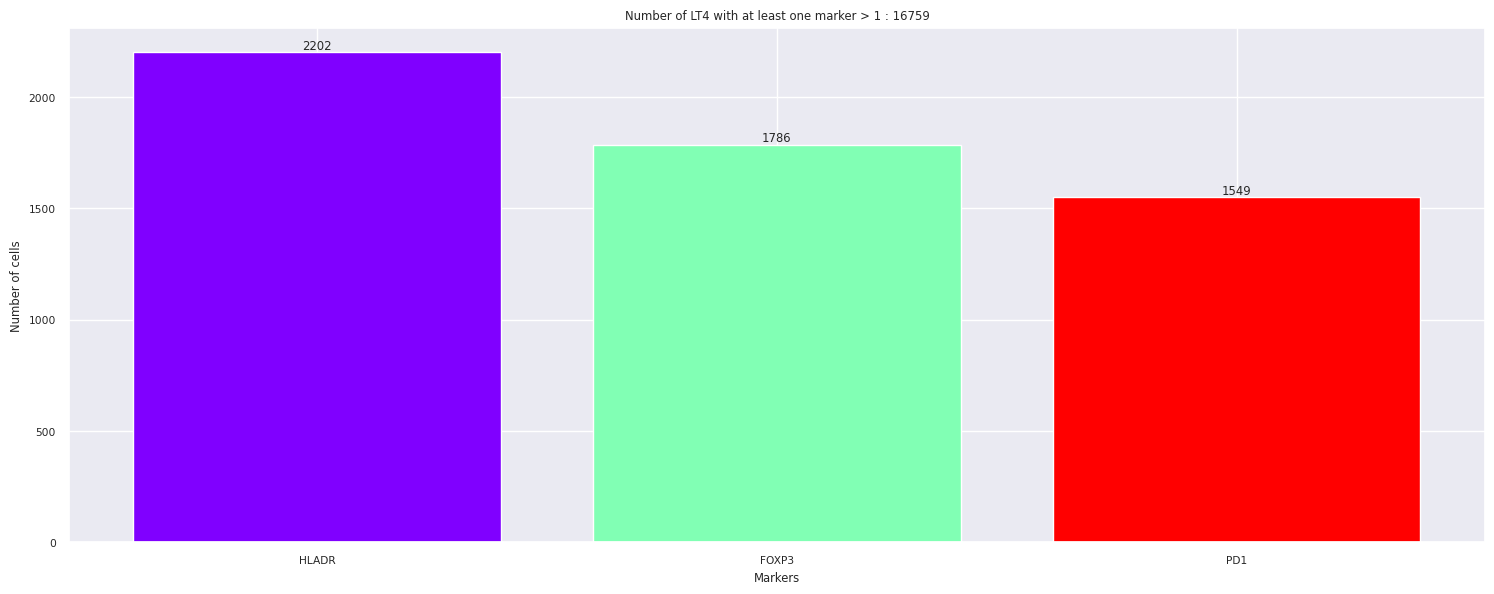

In [64]:
sns.set(font_scale=0.7)
thresh = 1
counts = (df_subpop_num > thresh).sum()

# Sort counts in descending order
counts_sorted = counts.sort_values(ascending=False)

# Create a list of colors
colors = plt.cm.rainbow(np.linspace(0, 1, len(counts_sorted)))

# Create the bar plot
plt.figure(figsize=(15, 6))
bars = plt.bar(counts_sorted.index, counts_sorted.values, color=colors)
plt.title("Number of "+pheno+" with at least one marker > " + str(thresh) + " : " + str(df_subpop.shape[0]))
plt.xlabel("Markers")
plt.ylabel("Number of cells")
plt.xticks(rotation=0)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2., height,
        f'{height}',
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.savefig(path_subpop + "main_markers_" + pheno + ".png")
plt.show()


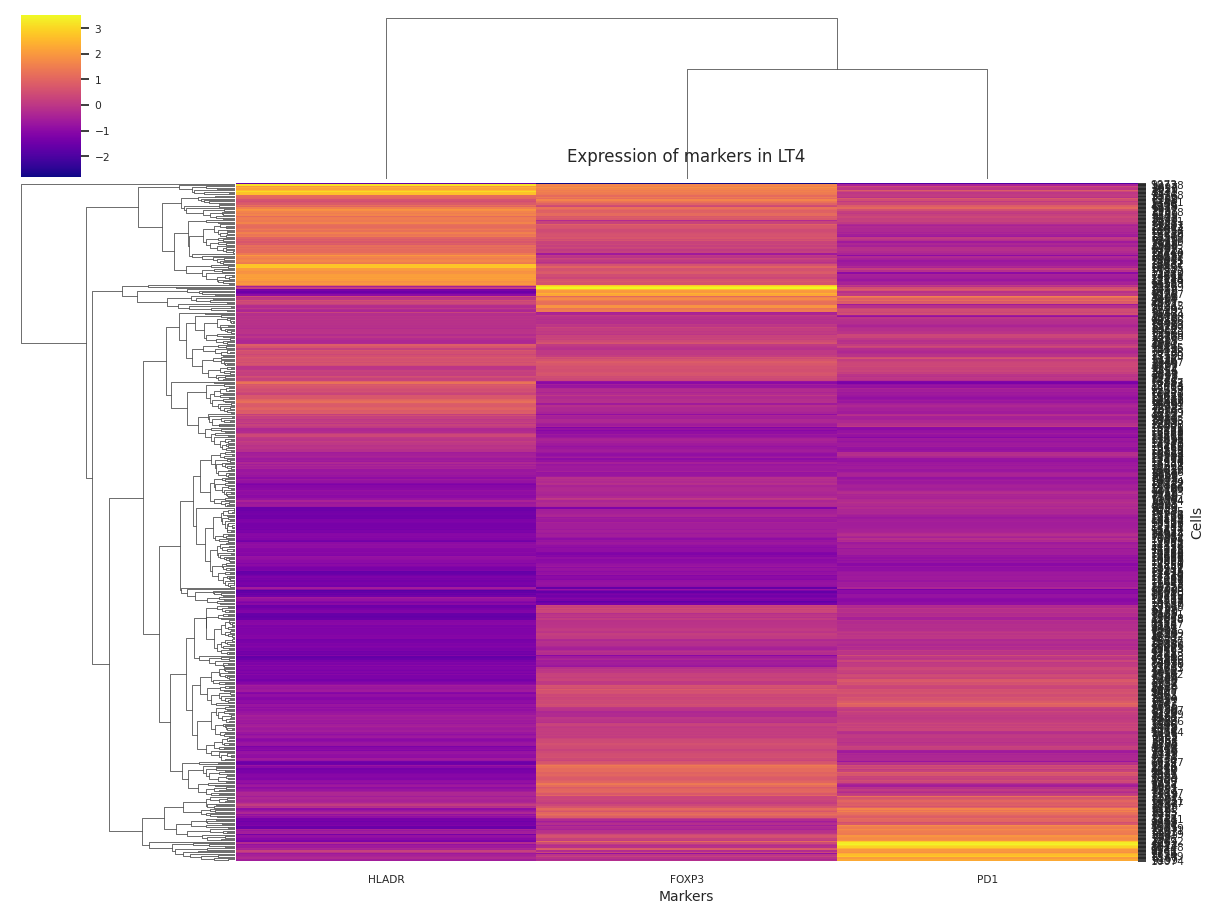

In [65]:
df_sample = df_subpop_num.sample(500)

g = sns.clustermap(
    df_sample,
    xticklabels=True,
    yticklabels=True,
    cmap='plasma',
    figsize=(12, 9)
)

# Set titles on the heatmap axis (not the global plt axes)
g.ax_heatmap.set_title(f"Expression of markers in {pheno}", fontsize=12, pad=15)
g.ax_heatmap.set_xlabel("Markers", fontsize=10)
g.ax_heatmap.set_ylabel("Cells", fontsize=10)

# Save figure
g.fig.savefig(path_subpop + "heatmap_cells.png", dpi=300, bbox_inches="tight")
plt.show()


### ⚙️ **Clustering using the markers selected by Hierarchical clustering algorithm (Ward)**
⚠️ USER INPUT REQUIRED  
*The goal is to determine the ideal number of clusters that best reflects the presence of major subpopulations within the phenotype being studied.*

#### Functions

In [66]:

def ward_clustering_umap(
    X,
    marker_names=None,
    min_k=2,
    max_k=10,
    standardize=True,
    method="ward",
    outdir=None,
    heatmap_cmap="viridis",
    pca_points_size=6,      # point size for UMAP scatter
    umap_n_neighbors=15,
    umap_min_dist=0.1,
    umap_metric="euclidean",
    umap_random_state=42,
):
    """
    Publication-ready Ward clustering visualization using UMAP.

    For each number of clusters k in [min_k, max_k], this function creates
    a single-row figure with four panels:
        1. Left: horizontal bar plot of cluster sizes (bars extend to the LEFT).
        2. Center-left: heatmap of average marker expression per cluster (+ annotations).
        3. Center-right: Ward dendrogram with branches colored by cluster
           (same colors as the UMAP scatter).
        4. Right: 2D UMAP projection with clusters in different colors.
    """

    # ---------- Convert to array ----------
    X = np.asarray(X)
    n_cells, n_markers = X.shape

    if marker_names is None:
        marker_names = [f"marker_{i}" for i in range(n_markers)]

    # ---------- Style (publication-ish) ----------
    sns.set_context("talk", font_scale=0.8)
    sns.set_style("whitegrid", {'axes.grid': False})

    # ---------- Standardization ----------
    if standardize:
        scaler = StandardScaler()
        X_proc = scaler.fit_transform(X)
    else:
        X_proc = X

    # ---------- Hierarchical clustering (Ward) ----------
    Z = linkage(X_proc, method=method)

    # Precompute members for each node in the tree (needed for coloring links)
    # Leaves: 0..n_cells-1, internal nodes: n_cells..n_cells+n_cells-2
    cluster_members = {i: np.array([i], dtype=int) for i in range(n_cells)}
    for node_id in range(n_cells, n_cells + n_cells - 1):
        row = node_id - n_cells
        left = int(Z[row, 0])
        right = int(Z[row, 1])
        members = np.concatenate([cluster_members[left], cluster_members[right]])
        cluster_members[node_id] = members

    # ---------- UMAP for visualization ----------
    reducer = umap.UMAP(
        n_neighbors=umap_n_neighbors,
        min_dist=umap_min_dist,
        metric=umap_metric,
        random_state=umap_random_state,
    )
    X_2d = reducer.fit_transform(X_proc)

    # ---------- Output dir ----------
    if outdir is not None:
        os.makedirs(outdir, exist_ok=True)

    # ---------- Loop over k ----------
    for k in range(min_k, max_k + 1):

        labels = fcluster(Z, t=k, criterion="maxclust")  # cluster labels (1..k en général)

        # Mean marker expression per cluster
        df_tmp = pd.DataFrame(X, columns=marker_names)
        df_tmp["cluster"] = labels
        mean_expr = df_tmp.groupby("cluster")[marker_names].mean()

        # Cluster sizes
        cluster_sizes = df_tmp["cluster"].value_counts().sort_index()

        # Ensure ordering of clusters
        mean_expr = mean_expr.loc[cluster_sizes.index]
        cluster_sizes_ordered = cluster_sizes.loc[mean_expr.index]
        n_clusters_k = mean_expr.shape[0]

        # ---------- Color mapping: cluster id -> color ----------
        cmap_clusters = plt.get_cmap("tab20", n_clusters_k)
        cluster_ids = list(mean_expr.index)  # e.g. [1, 2, ..., k]

        cluster_to_color = {
            cid: cmap_clusters(i)
            for i, cid in enumerate(cluster_ids)
        }

        # Colors for each cell (for UMAP scatter)
        point_colors = [cluster_to_color[cid] for cid in labels]

        # Colors for each node in the dendrogram
        node_color = {}
        for node_id, members in cluster_members.items():
            cluster_ids_node = np.unique(labels[members])
            if len(cluster_ids_node) == 1:
                # Node belongs entirely to a single flat cluster: use that cluster color
                rgb = cluster_to_color[cluster_ids_node[0]]
                node_color[node_id] = to_hex(rgb)   # convert RGBA -> hex string
            else:
                # Mixed node: neutral gray
                node_color[node_id] = "#808080"

        def link_color_func(node_id: int):
            # node_id is the index of a leaf or internal node (0..)
            return node_color.get(node_id, "#808080")

        # ---------- Figure layout ----------
        fig = plt.figure(
            figsize=(8 + 0.5 * n_markers, 4),
            constrained_layout=True
        )

        gs = fig.add_gridspec(
            1, 4,
            width_ratios=[0.45, 1.8, 1.6, 2.1],
            wspace=0.02
        )

        ax_bar = fig.add_subplot(gs[0, 0])
        ax_hm  = fig.add_subplot(gs[0, 1])
        ax_den = fig.add_subplot(gs[0, 2])
        ax_sc  = fig.add_subplot(gs[0, 3])

        # ============================================================
        # 1) BARPLOT (cluster sizes, left-oriented, glued to heatmap)
        # ============================================================
        y_positions = np.arange(n_clusters_k)
        counts = cluster_sizes_ordered.values
        max_count = counts.max()

        ax_bar.barh(
            y_positions,
            counts,
            color="0.6"
        )

        ax_bar.invert_yaxis()
        ax_bar.invert_xaxis()

        # Clean visuals
        for spine in ax_bar.spines.values():
            spine.set_visible(False)
        ax_bar.set_xticks([])
        ax_bar.set_yticks([])

        # Extend x-limit so text fits on far left
        ax_bar.set_xlim(max_count * 1.25, 0)

        # Text labels LEFT of bar
        for y, val in zip(y_positions, counts):
            ax_bar.text(
                max_count * 1.23,
                y,
                str(val),
                ha="right",
                va="center",
                fontsize=9
            )

        ax_bar.set_xlabel("Cells", fontsize=9, labelpad=4)

        # ============================================================
        # 2) HEATMAP (with annotations)
        # ============================================================
        annot_values = np.round(mean_expr.values, 2)

        sns.heatmap(
            mean_expr,
            ax=ax_hm,
            cmap=heatmap_cmap,
            cbar=True,
            xticklabels=marker_names,
            yticklabels=[f"C{c}" for c in mean_expr.index],
            cbar_kws={"shrink": 0.7},
            annot=annot_values,
            fmt="",
            annot_kws={"fontsize": 7}
        )

        ax_hm.set_title(f"Average marker expression – {k} clusters", fontsize=11, pad=8)
        ax_hm.set_xlabel("Markers", fontsize=9)
        ax_hm.set_ylabel("Cluster", fontsize=9)

        ax_hm.yaxis.tick_right()
        ax_hm.yaxis.set_label_position("right")
        ax_hm.tick_params(axis="both", labelsize=8)

        # ============================================================
        # 3) DENDROGRAM + cut line, colored by flat clusters
        # ============================================================
        dendrogram(
            Z,
            ax=ax_den,
            no_labels=True,
            color_threshold=None,
            link_color_func=link_color_func
        )
        ax_den.set_title("Dendrogram (Ward)", fontsize=11, pad=8)
        ax_den.set_xlabel("Cells", fontsize=9)
        ax_den.set_ylabel("Distance", fontsize=9)
        ax_den.tick_params(axis="both", labelsize=8)

        # Add horizontal cut for k clusters
        if 1 <= k <= n_cells - 1:
            cut_height = Z[n_cells - k - 1, 2]
            ax_den.axhline(y=cut_height, color="red", linestyle="--", linewidth=1)
            ax_den.text(
                0.02,
                cut_height,
                f"k = {k}",
                color="red",
                fontsize=8,
                va="bottom",
                ha="left",
                transform=ax_den.get_yaxis_transform()
            )

        # ============================================================
        # 4) UMAP SCATTER (cluster-colored, same colors as dendrogram)
        # ============================================================
        scatter = ax_sc.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            c=point_colors,
            s=pca_points_size,
            edgecolor="none",
            alpha=0.9
        )

        ax_sc.set_title("UMAP 2D", fontsize=11, pad=8)
        ax_sc.set_xlabel("UMAP 1", fontsize=9)
        ax_sc.set_ylabel("UMAP 2", fontsize=9)
        ax_sc.tick_params(axis="both", labelsize=8)

        # Legend using cluster_to_color mapping
        legend_handles = [
            Patch(color=cluster_to_color[cid], label=f"C{cid}")
            for cid in cluster_ids
        ]
        ax_sc.legend(
            handles=legend_handles,
            title="Clusters",
            fontsize=8,
            title_fontsize=9,
            frameon=False,
            loc="best"
        )

        # ============================================================
        # Title (with spacing)
        # ============================================================
        fig.suptitle(
            f"Ward clustering (k = {k})",
            fontsize=13,
            y=1.07,
        )

        # ============================================================
        # SAVE FIGURE
        # ============================================================
        if outdir is not None:
            fname = os.path.join(outdir, f"ward_umap_panels_k{k}.png")
            fig.savefig(fname, dpi=300, bbox_inches="tight")
            print(f"✅ The files concerning the heatmap of {pheno} subpopulations can be found in the following folder:  {path_heatmap_subpop}")


        plt.show()


In [67]:
from scipy.cluster.hierarchy import linkage, fcluster

def assign_clusters_ward(df, marker_cols, k=5):
    X = df[marker_cols].values

    scaler = StandardScaler()
    X_proc = scaler.fit_transform(X)

    Z = linkage(X_proc, method="ward")

    labels = fcluster(Z, t=k, criterion="maxclust")
    df["cluster"] = labels

    print(f"Clusters assigned (k = {k})")
    print(df["cluster"].value_counts().sort_index())

    return df, labels



#### Hierarchical clustering using the Ward method

In [68]:
path_heatmap_subpop=path_subpop+"Agglomerative_hierarchical_clustering"
if os.path.isdir(path_heatmap_subpop)==False:
  os.mkdir(path_heatmap_subpop)
  print(f"✅ The files concerning the heatmap of {pheno} subpopulations can be found in the following folder:  {path_heatmap_subpop}")

In [71]:
df_subpop_num=pd.read_csv(path_subpop+"mfi_"+pheno+"_subpop.csv")
df_subpop_num=df_subpop_num.drop(["label","ROI"],axis=1)
df_subpop_num.head()

,FOXP3,HLADR,PD1
0,2.138132,3.062035,1.497794
1,-0.378150,-0.685014,2.432714
2,-0.287683,-1.348972,-0.240394
3,0.068727,-0.936490,0.409420
4,0.441679,-0.485195,0.128908


In [72]:
k_max=int(input(f"Enter the maximum number of {pheno} subpopulations:"))

Enter the maximum number of LT4 subpopulations:10


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ The files concerning the heatmap of LT4 subpopulations can be found in the following folder:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/Agglomerative_hierarchical_clustering


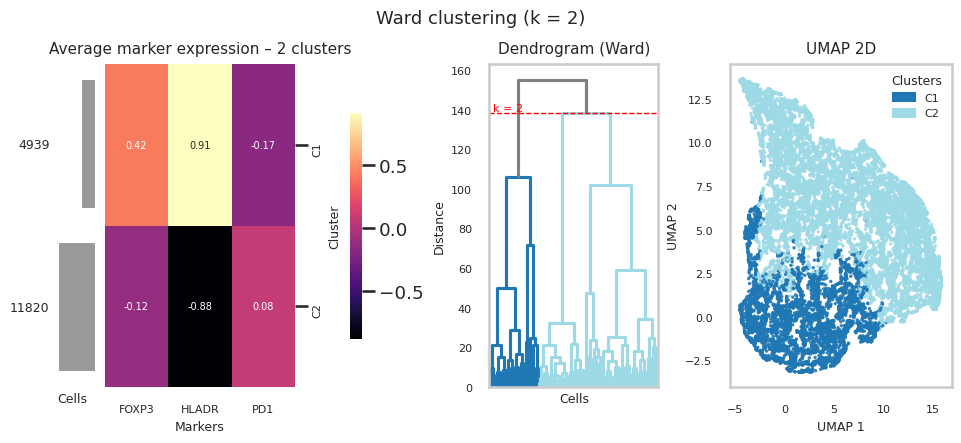

✅ The files concerning the heatmap of LT4 subpopulations can be found in the following folder:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/Agglomerative_hierarchical_clustering


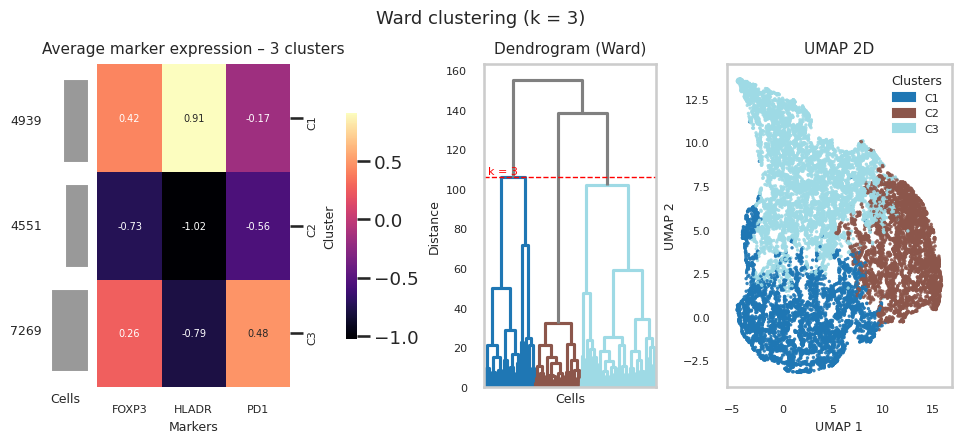

✅ The files concerning the heatmap of LT4 subpopulations can be found in the following folder:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/Agglomerative_hierarchical_clustering


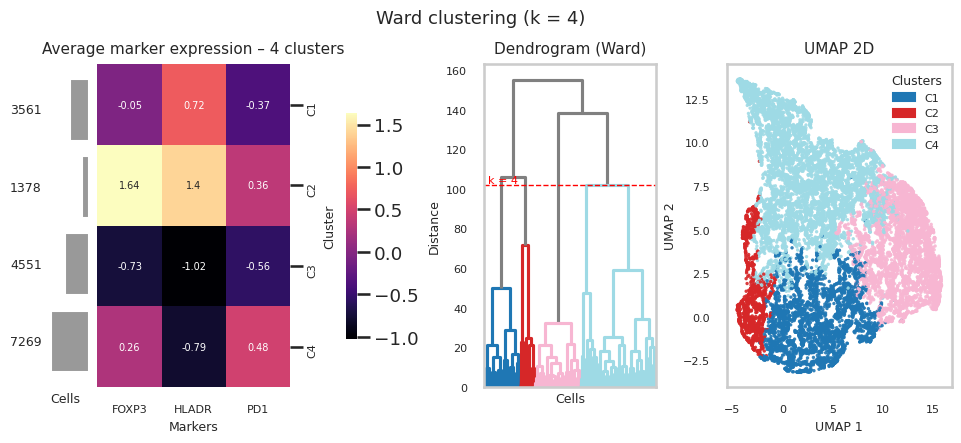

✅ The files concerning the heatmap of LT4 subpopulations can be found in the following folder:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/Agglomerative_hierarchical_clustering


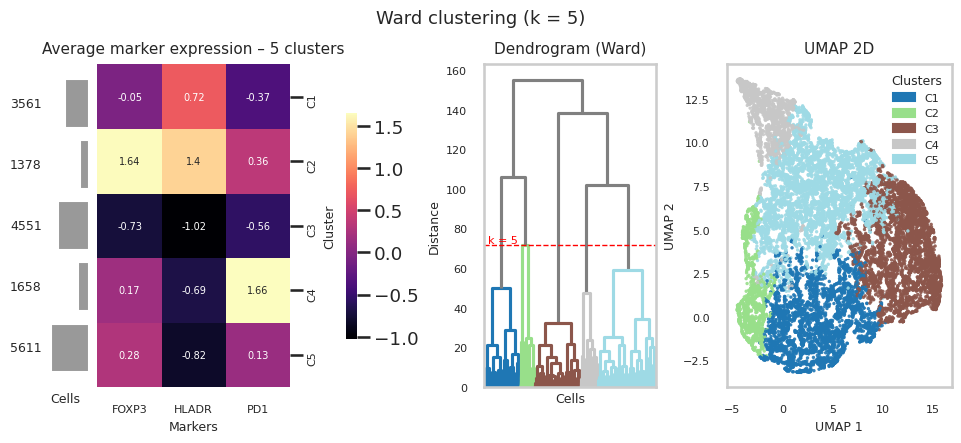

✅ The files concerning the heatmap of LT4 subpopulations can be found in the following folder:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/Agglomerative_hierarchical_clustering


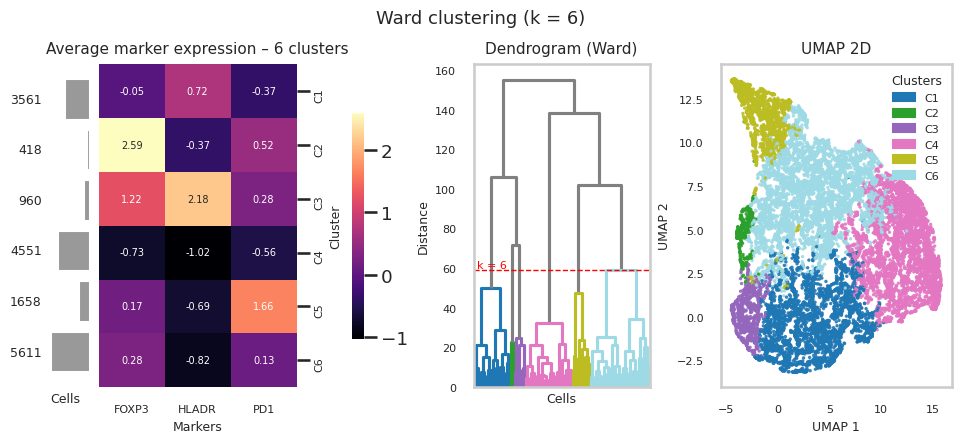

✅ The files concerning the heatmap of LT4 subpopulations can be found in the following folder:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/Agglomerative_hierarchical_clustering


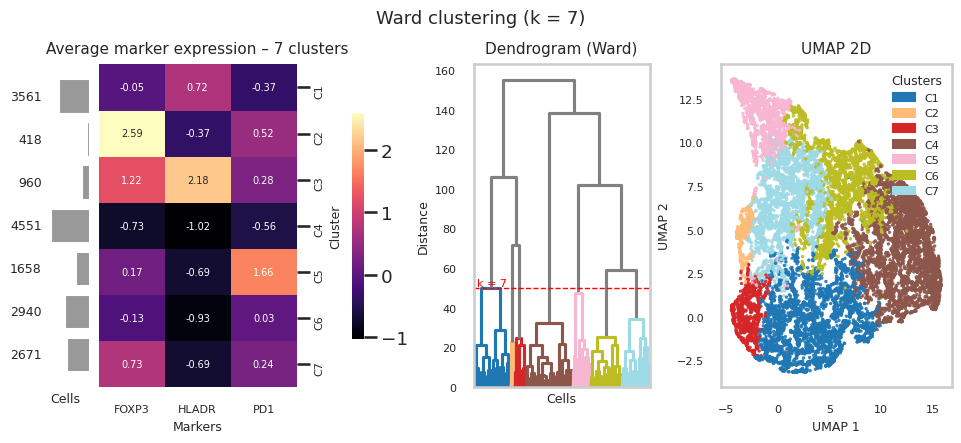

✅ The files concerning the heatmap of LT4 subpopulations can be found in the following folder:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/Agglomerative_hierarchical_clustering


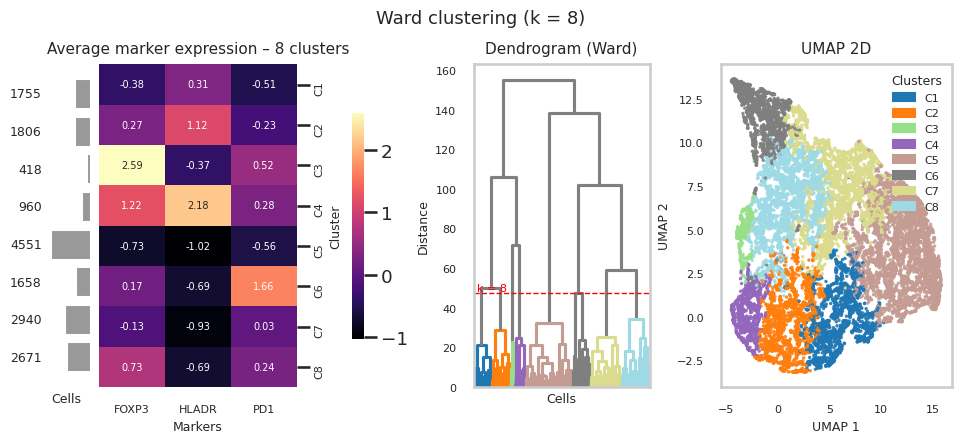

✅ The files concerning the heatmap of LT4 subpopulations can be found in the following folder:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/Agglomerative_hierarchical_clustering


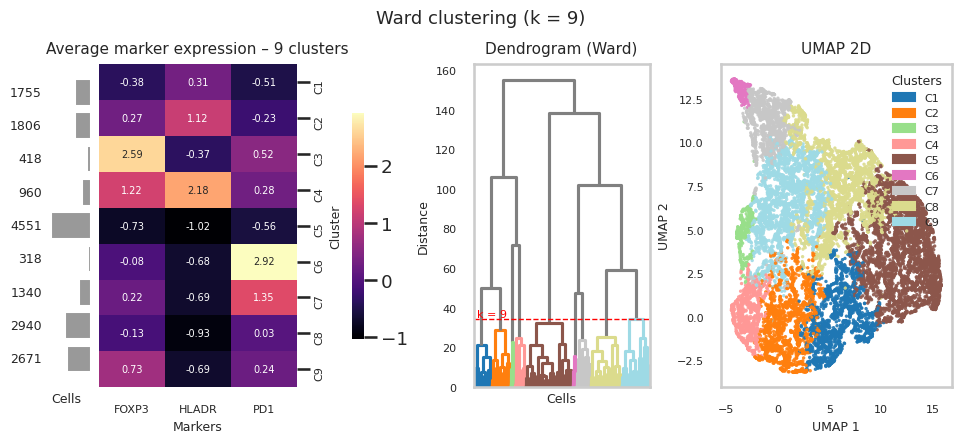

✅ The files concerning the heatmap of LT4 subpopulations can be found in the following folder:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/Agglomerative_hierarchical_clustering


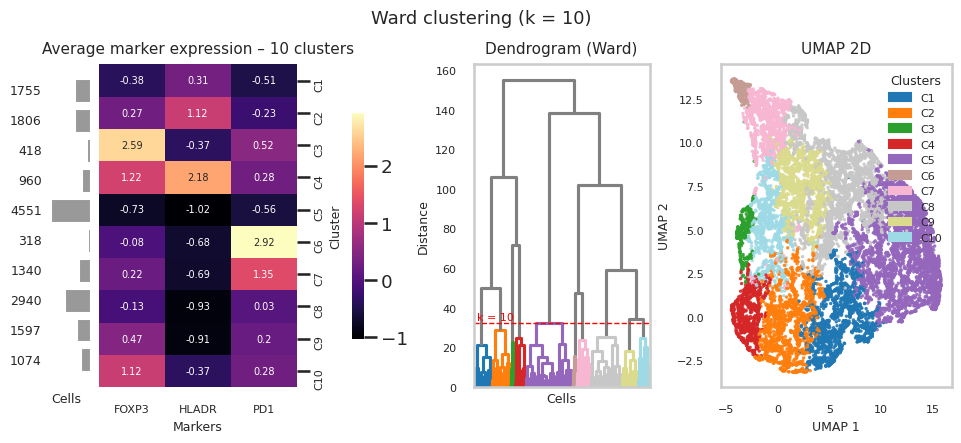

In [73]:

X = df_subpop_num.values
marker_names = df_subpop_num.columns.tolist()

ward_clustering_umap(
    X,
    marker_names=marker_names,
    min_k=2,
    max_k=k_max,
    outdir=path_heatmap_subpop,
    heatmap_cmap="magma",
    umap_n_neighbors=15,
    umap_min_dist=0.1,
)


In [74]:
k_final=int(input("Enter the best number of clusters to do the phenotype annotation: "))
marker_cols = df_subpop_num.columns.tolist()
df_cluster, labels = assign_clusters_ward(df_subpop, marker_cols, k=k_final)
df_cluster.to_csv(path_subpop+f"mfi_{pheno}_subpop_cluster.csv",index=False)
print(f"✅ The dataframe with the clusters of {pheno} subpopulations can be found in the following folder:{path_subpop}mfi_{pheno}_subpop_cluster.csv")
df_cluster.head()

Enter the best number of clusters to do the phenotype annotation: 7
Clusters assigned (k = 7)
cluster
1    3561
2     418
3     960
4    4551
5    1658
6    2940
7    2671
Name: count, dtype: int64
✅ The dataframe with the clusters of LT4 subpopulations can be found in the following folder:/content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/mfi_LT4_subpop_cluster.csv


,FOXP3,HLADR,PD1,ROI,label,cluster
62,2.138132,3.062035,1.497794,ROI,71,3
103,-0.378150,-0.685014,2.432714,ROI,112,5
152,-0.287683,-1.348972,-0.240394,ROI,164,4
153,0.068727,-0.936490,0.409420,ROI,165,6
157,0.441679,-0.485195,0.128908,ROI,169,7


### 📊 **Heatmap of marker expression across clusters**
*Heatmap showing the expression of the selected markers in the different clusters*

#### Functions

In [84]:
def heatmap_histo(df, name_value, title, path, threshold, vmin, vmax):

    sns.set(font_scale=1)

    # --- Data ---
    data = df.groupby(name_value).mean()
    counts = df[name_value].value_counts().sort_index()

    linkage_result = linkage(data, method="ward")
    order = leaves_list(linkage_result)
    data = data.iloc[order]
    counts = counts.iloc[order]

    n_clusters = len(data)
    fig = plt.figure(figsize=(10, max(6, n_clusters * 0.4)))
    fig.patch.set_facecolor('white')
    gs = GridSpec(nrows=1, ncols=2, width_ratios=[1.2, 5], wspace=0.02)

    # --- Histogram ---
    ax_bar = fig.add_subplot(gs[0])
    y_positions = [i + 0.5 for i in range(n_clusters)]

    bars = ax_bar.barh(
        y=y_positions,
        width=counts.values,
        height=1,
        color='gray'
    )

    # Add cell counts inside the histogram
    for y, count in zip(y_positions, counts.values):
        ax_bar.text(
            count - 1,
            y,
            str(count),
            va='center',
            ha='right',
            fontsize=8
        )

    ax_bar.set_yticks([])
    ax_bar.invert_xaxis()
    ax_bar.set_xlabel("")
    ax_bar.set_xticks([])
    ax_bar.xaxis.set_label_position('top')
    ax_bar.set_facecolor('none')
    ax_bar.yaxis.set_ticks_position('none')

    for spine in ['top', 'right', 'bottom']:
        ax_bar.spines[spine].set_visible(False)

    # --- NEW: Left-side legend for histogram ---
    ax_bar.set_ylabel("Number of cells", fontsize=11, labelpad=25, rotation=90)
    ax_bar.yaxis.set_label_position("left")

    # --- Heatmap ---
    ax_heatmap = fig.add_subplot(gs[1])
    heatmap = sns.heatmap(
        data,
        ax=ax_heatmap,
        vmin=vmin,
        vmax=vmax,
        cmap="vlag",
        linewidths=0.5,
        linecolor='gray',
        xticklabels=True,
        yticklabels=False,
        cbar=False
    )

    ax_heatmap.set_yticks([i + 0.5 for i in range(n_clusters)])
    ax_heatmap.set_yticklabels(data.index, fontsize=12)
    ax_heatmap.yaxis.tick_right()
    ax_heatmap.yaxis.set_label_position("right")

    # Align histogram with heatmap height
    ax_bar.set_ylim(ax_heatmap.get_ylim())

    # --- Red boxes above threshold ---
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data.iloc[i, j]
            if value > threshold:
                rect = Rectangle((j, i), 1, 1, linewidth=2, edgecolor='red', facecolor='none')
                ax_heatmap.add_patch(rect)

    # --- Main title ---
    fig.suptitle(title, fontsize=16, y=1.05)

    # --- Colorbar above heatmap ---
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.cm as cm

    norm = plt.Normalize(vmin=data.values.min(), vmax=data.values.max())
    sm = plt.cm.ScalarMappable(cmap="vlag", norm=norm)
    sm.set_array([])

    cax = fig.add_axes([0.13, 0.94, 0.3, 0.015])
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=8)

    # --- Save ---
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(path + f"Heatmap_{name_value}.png", bbox_inches='tight')
    print(f"✅ The dataframe with the clusters of {pheno} subpopulations can be found in the following folder:{path}Heatmap_{name_value}.png")
    plt.show()


#### Execution

/tmp/ipython-input-3912149212.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


✅ The dataframe with the clusters of LT4 subpopulations can be found in the following folder:/content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/Heatmap_cluster.png


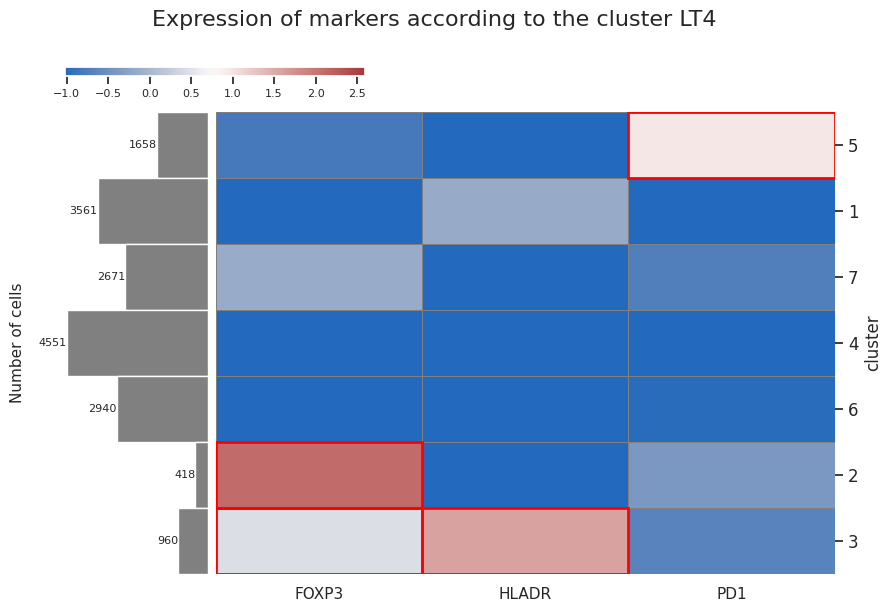

In [85]:
df_subpop_cluster = pd.read_csv(path_subpop+"mfi_"+pheno+"_subpop_cluster.csv")
df_subpop_cluster_marker = df_subpop_cluster.drop(["label", "ROI"], axis=1)

heatmap_histo(df_subpop_cluster_marker,"cluster","Expression of markers according to the cluster "+pheno,path_subpop,threshold=1,vmin=0,vmax=3)


### 📊 **Distribution of the clusters across the different biopsies**
*Distribution of selected MFIs Cluster by cluster*



In [81]:
path_clust_roi=path_subpop+"proportion_cluster_roi/"
if os.path.isdir(path_clust_roi)==False:
  os.mkdir(path_clust_roi)

In [82]:
df_subpop_cluster=pd.read_csv(path_subpop+"mfi_"+pheno+"_subpop_cluster.csv")

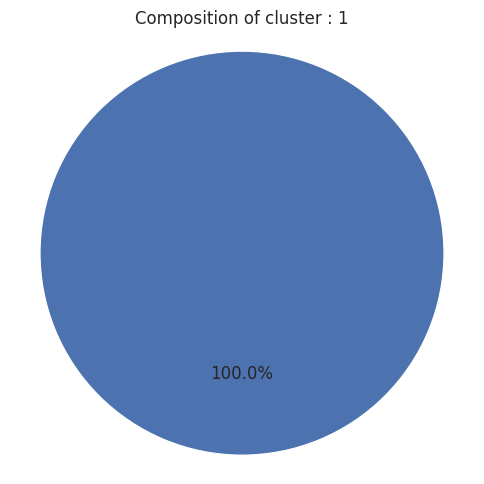

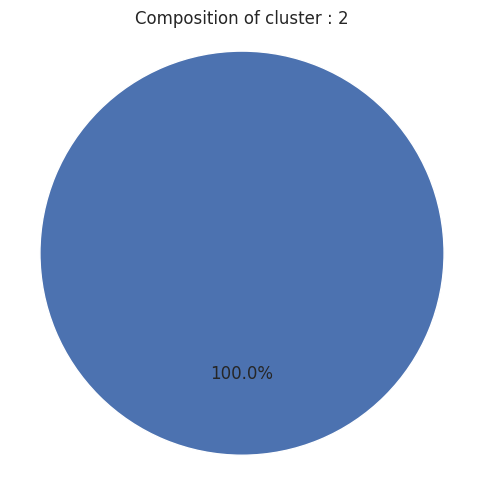

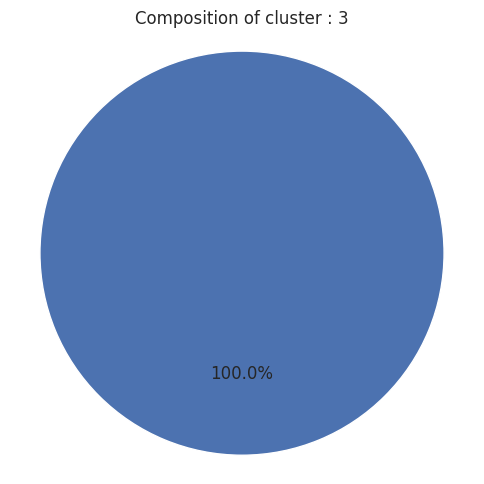

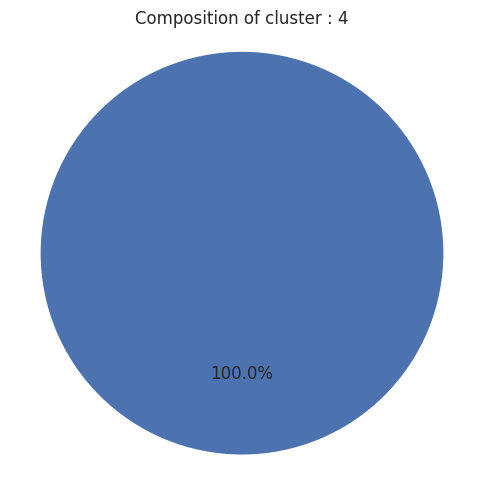

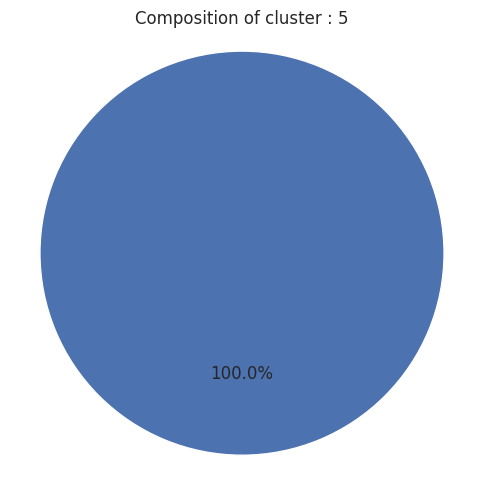

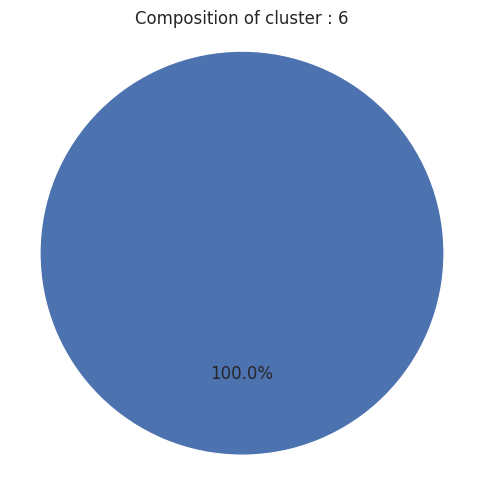

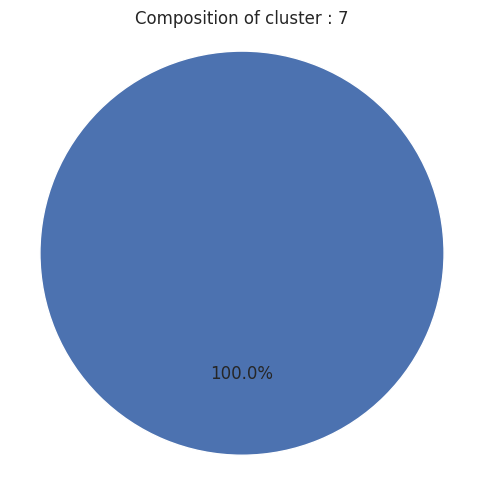

In [83]:

patients_df = df_subpop_cluster[['cluster',"ROI"]]
grouped = patients_df.groupby('cluster')['ROI'].value_counts().unstack(fill_value=0)

def show_if_gt_10(pct):
    return f'{pct:.1f}%' if pct > 10 else ''

for group, row in grouped.iterrows():
    labels = row.index
    sizes = row.values

    plt.figure(figsize=(5, 5))
    plt.pie(sizes,autopct=show_if_gt_10, startangle=90)
    plt.title(f"Composition of cluster : {group}")
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(path_clust_roi+"pie_chart_cluster_"+str(group)+".png")
    plt.show()


### 📊 **Dotplot coexpression of markers within the clusters**
⚠️ USER INPUT REQUIRED  
*Graph showing the co-expression of markers 2 by 2 in each cluster*

#### Functions

In [86]:

def plot_density_df(df, marker_x, marker_y, path_out, pheno,
                    palette='tab10',
                    x_thresh=None, y_thresh=None):
    """
    Plots the 2D density of a pair of markers and adds:
      - Red threshold lines (x_thresh, y_thresh)
      - A summary of counts and percentages:
        X+, Y+, double+, double-
    """

    plt.figure(figsize=(8, 6))
    x = df[marker_x].values
    y = df[marker_y].values

    # Compute local density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    # Sort points so that denser points appear on top
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    # Scatter plot colored by density
    sc = plt.scatter(x, y, c=z, cmap='viridis', s=3,
                     edgecolor='none', alpha=0.7)

    # 2D density contour lines
    sns.kdeplot(x=x, y=y, levels=5, linewidths=1,
                color='black', alpha=0.6)

    # Add threshold lines if provided
    if x_thresh is not None:
        plt.axvline(x=x_thresh, color='red', linestyle='--',
                    linewidth=1.5, alpha=0.8)
    if y_thresh is not None:
        plt.axhline(y=y_thresh, color='red', linestyle='--',
                    linewidth=1.5, alpha=0.8)

    # Compute quadrant populations if thresholds are available
    if x_thresh is not None and y_thresh is not None:
        x_pos = x > x_thresh
        y_pos = y > y_thresh

        n_total = len(x)
        n_xpos = np.sum(x_pos)
        n_ypos = np.sum(y_pos)
        n_double_pos = np.sum(x_pos & y_pos)
        n_double_neg = np.sum(~x_pos & ~y_pos)

        # Percentages
        p_xpos = 100 * n_xpos / n_total
        p_ypos = 100 * n_ypos / n_total
        p_double_pos = 100 * n_double_pos / n_total
        p_double_neg = 100 * n_double_neg / n_total

        # Text box content
        txt = (
            f"Total cells: {n_total}\n"
            f"{marker_x}+ : {n_xpos} ({p_xpos:.1f}%)\n"
            f"{marker_y}+ : {n_ypos} ({p_ypos:.1f}%)\n"
            f"Double + : {n_double_pos} ({p_double_pos:.1f}%)\n"
            f"Double - : {n_double_neg} ({p_double_neg:.1f}%)"
        )

        # Display in upper-right corner
        plt.text(
            0.98, 0.98, txt, transform=plt.gca().transAxes,
            fontsize=9, color='white', fontweight='bold',
            ha='right', va='top',
            bbox=dict(facecolor='black', alpha=0.5,
                      boxstyle='round,pad=0.4'))

    # Labels and title
    plt.xlabel(marker_x)
    plt.ylabel(marker_y)
    plt.title(f"{marker_x} vs {marker_y} in cluster {pheno}")

    # Colorbar for density
    plt.colorbar(sc, label='Density')

    plt.tight_layout()
    plt.savefig(path_out + f"/{marker_x}_{marker_y}.png", dpi=300)
    print(f"✅ The graph can be found there:  {path_out}/{marker_x}_{marker_y}.png")
    plt.show()


#### Execution

In [87]:
path_coexpression=path_subpop+"coexpression_clusters/"
if os.path.isdir(path_coexpression)==False:
  os.mkdir(path_coexpression)

In [89]:
df_subpop_cluster=pd.read_csv(path_subpop+"mfi_"+pheno+"_subpop_cluster.csv")
df_subpop_num=df_subpop_cluster.drop(["label","ROI","cluster"],axis=1)
df_subpop_num.head()

,FOXP3,HLADR,PD1
0,2.138132,3.062035,1.497794
1,-0.378150,-0.685014,2.432714
2,-0.287683,-1.348972,-0.240394
3,0.068727,-0.936490,0.409420
4,0.441679,-0.485195,0.128908


In [ ]:
marker_names = df_subpop_num.columns.tolist()
for cluster in np.unique(df_subpop_cluster["cluster"]):
  path_coexpression_cluster=path_coexpression+"cluster_"+str(cluster)+"/"
  if os.path.isdir(path_coexpression_cluster)==False:
    os.mkdir(path_coexpression_cluster)
  for m1 in range(len(marker_names)):
   for m2 in range(m1,len(marker_names)):
    if m1!=m2:
        plot_density_df(df_subpop_cluster,marker_names[m1],marker_names[m2],path_out=path_coexpression_cluster,pheno=cluster,x_thresh=0,y_thresh=0)

### 📊 **Plot of MFI by cluster**
*Graph showing the distribution of Mfi clusters by cluster*

#### Function

In [112]:
def plot_mfi_cluster(df_mfi, path_file, thresh=1.5):

    list_cluster = sorted(df_mfi["cluster"].unique())
    for cluster in list_cluster:
        print("Cluster: " + str(cluster))
        list_data = []
        nb_cell = len(df_mfi.loc[df_mfi.loc[:, "cluster"] == cluster])
        nb_tot = df_mfi.shape[0]
        list_marker = df_mfi.columns[:-1]
        list_col = []

        for m in list_marker:
            list_m = list(df_mfi.loc[df_mfi.loc[:, "cluster"] == cluster][m])
            list_data.append(list_m)

        for i in range(len(list_data)):
            if np.mean(list_data[i]) > thresh:
                list_col.append("red")
            else:
                list_col.append("blue")

        pos = [float(p) for p in range(0, len(list_data))]
        fig, ax = plt.subplots(1, 1, figsize=(60, 10))

        violin = ax.violinplot(list_data, pos, showextrema=False, showmedians=True)

        c = 0
        for pc in violin['bodies']:
            pc.set_facecolor(list_col[c])
            c += 1

        # ➜ Ligne horizontale y = 0
        ax.axhline(y=0, color='black', linestyle='--', linewidth=2,zorder=0)

        ax.set_title(
            "Cluster: " + str(cluster) +
            " ( Nb of cells " + str(nb_cell) + " / " + str(nb_tot) + " )",
            fontsize=40
        )
        ax.set_xticks(np.arange(0, len(list_marker)), list_marker, size=25)
        ax.tick_params(axis='y', labelsize=20)
        plt.ylabel("Z-score", size=30)

        plt.savefig(path_file + str(cluster) + ".png")


#### Execution

In [113]:
if os.path.isdir(path_subpop+"plot_mfi_cluster/")==False:
  os.mkdir(path_subpop+"plot_mfi_cluster/")

In [114]:
df_subpop_cluster_marker=pd.read_csv(path_subpop+"mfi_"+pheno+"_subpop_cluster.csv")
df_subpop_cluster_marker=df_subpop_cluster_marker.drop(["label","ROI"],axis=1)

Cluster: 1
Cluster: 2
Cluster: 3
Cluster: 4
Cluster: 5
Cluster: 6
Cluster: 7


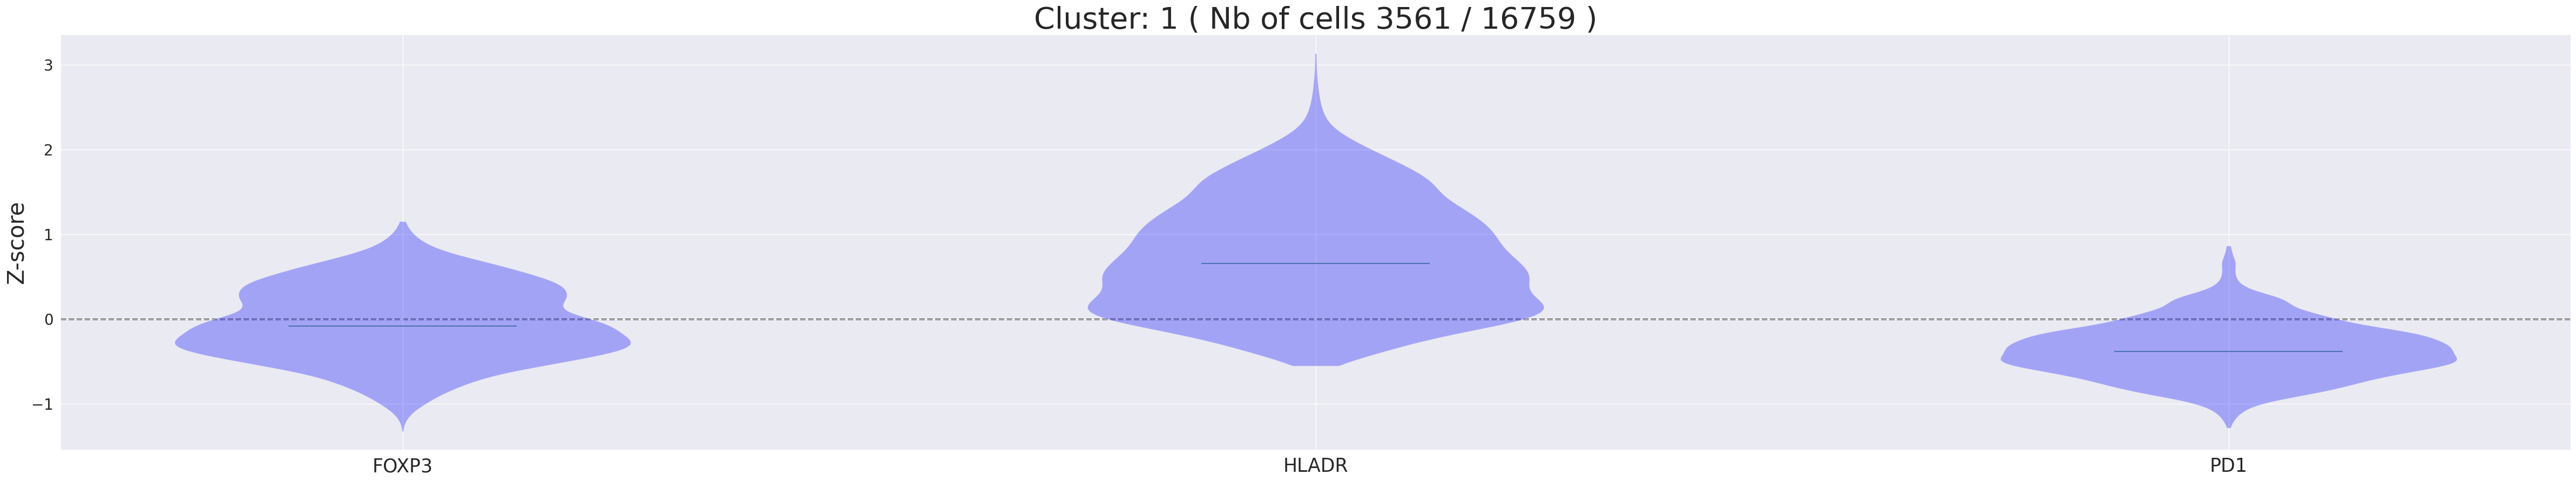

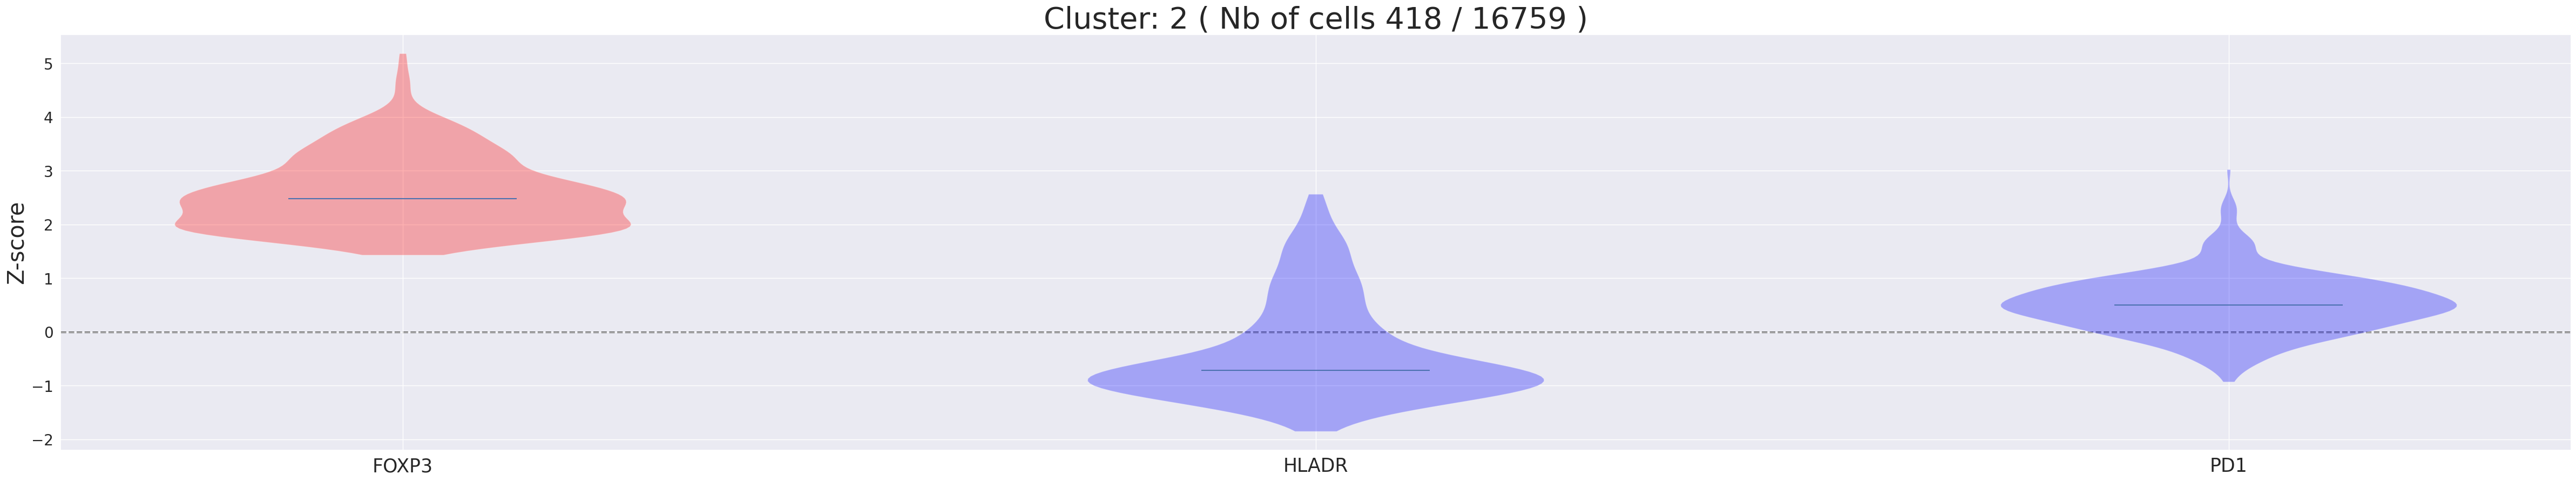

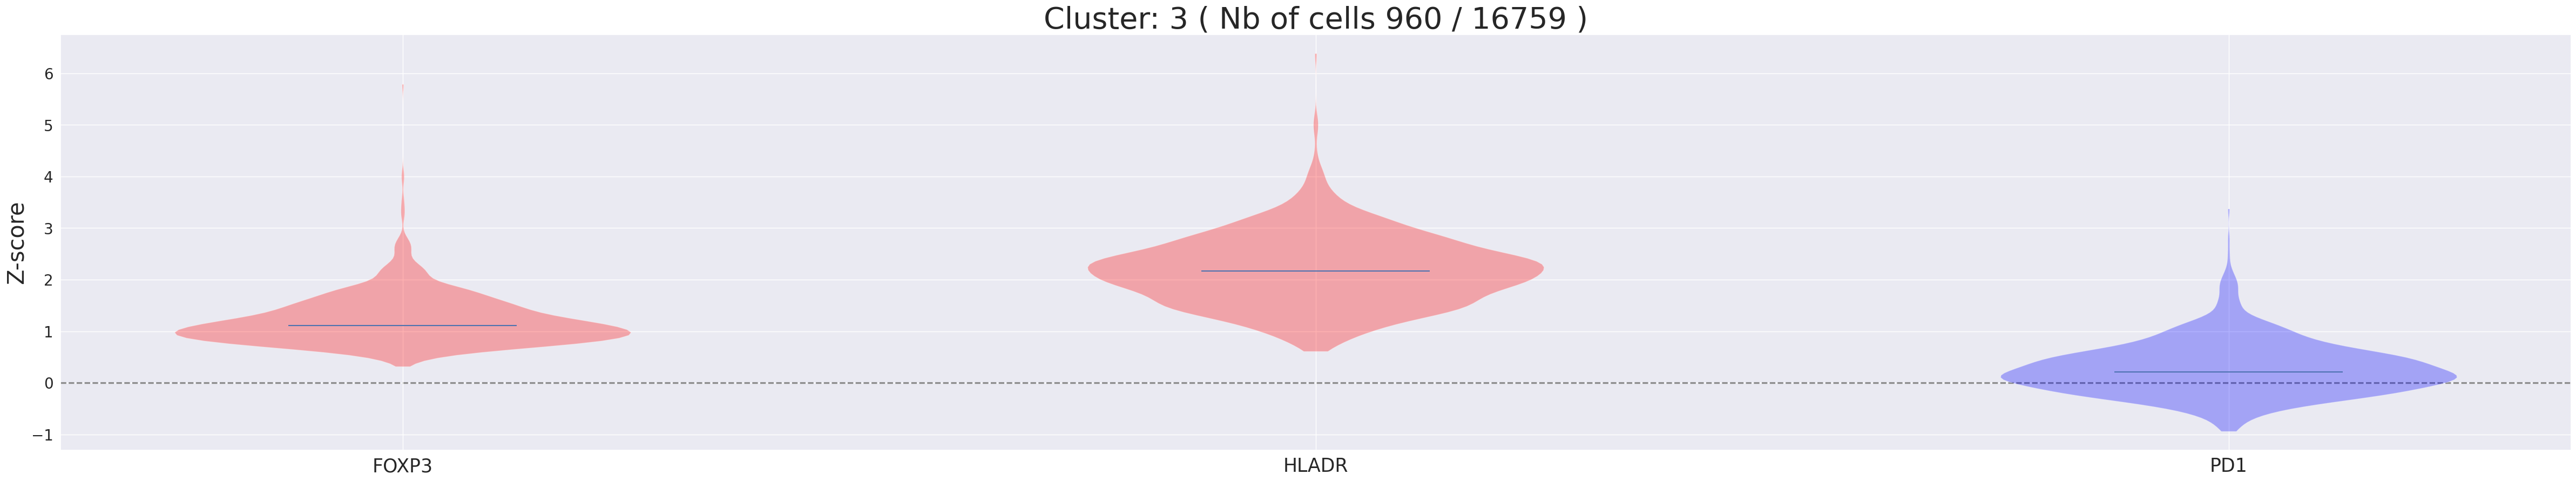

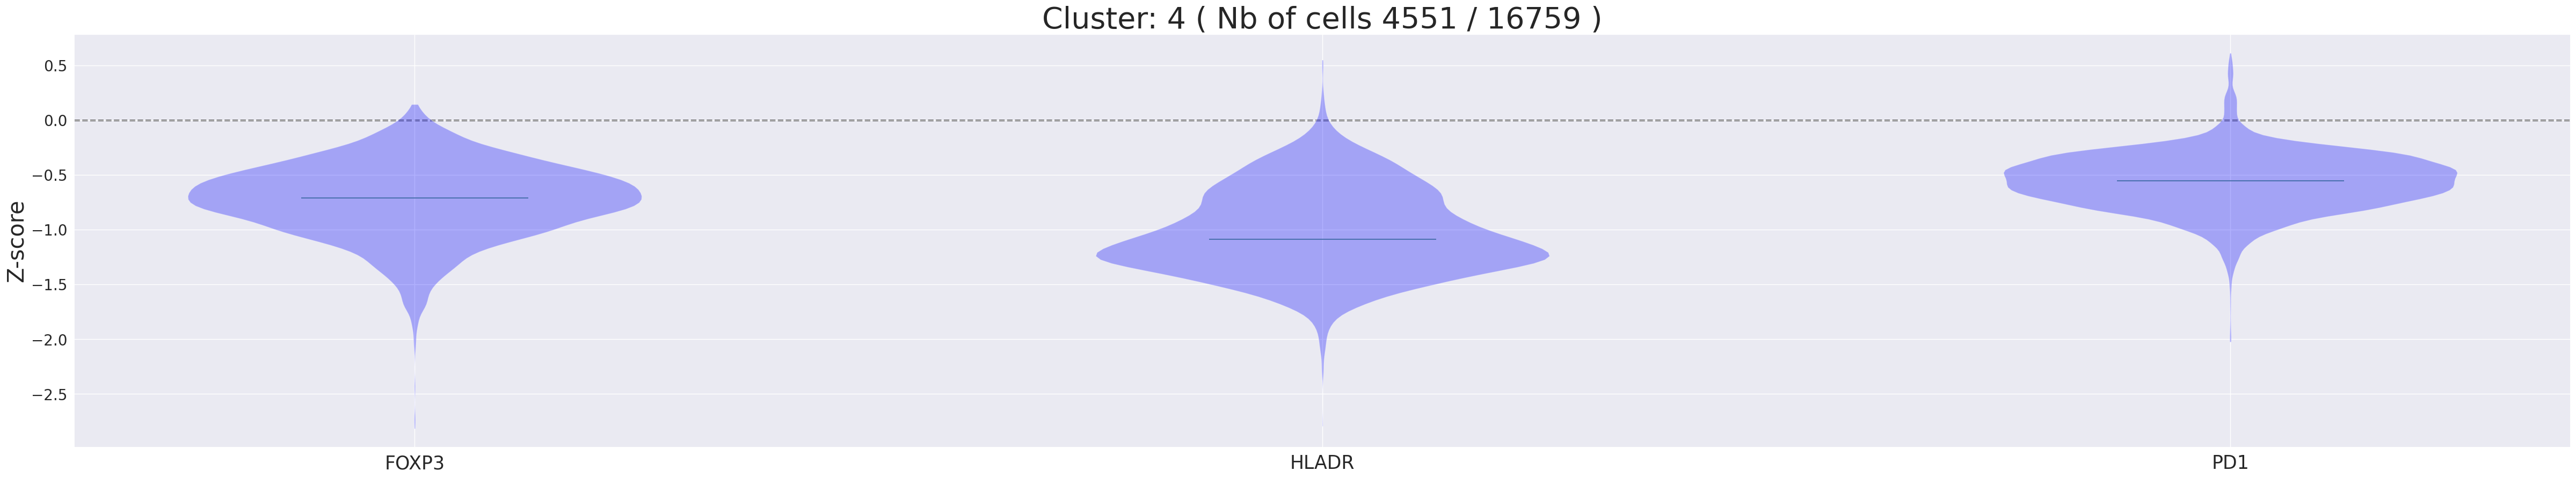

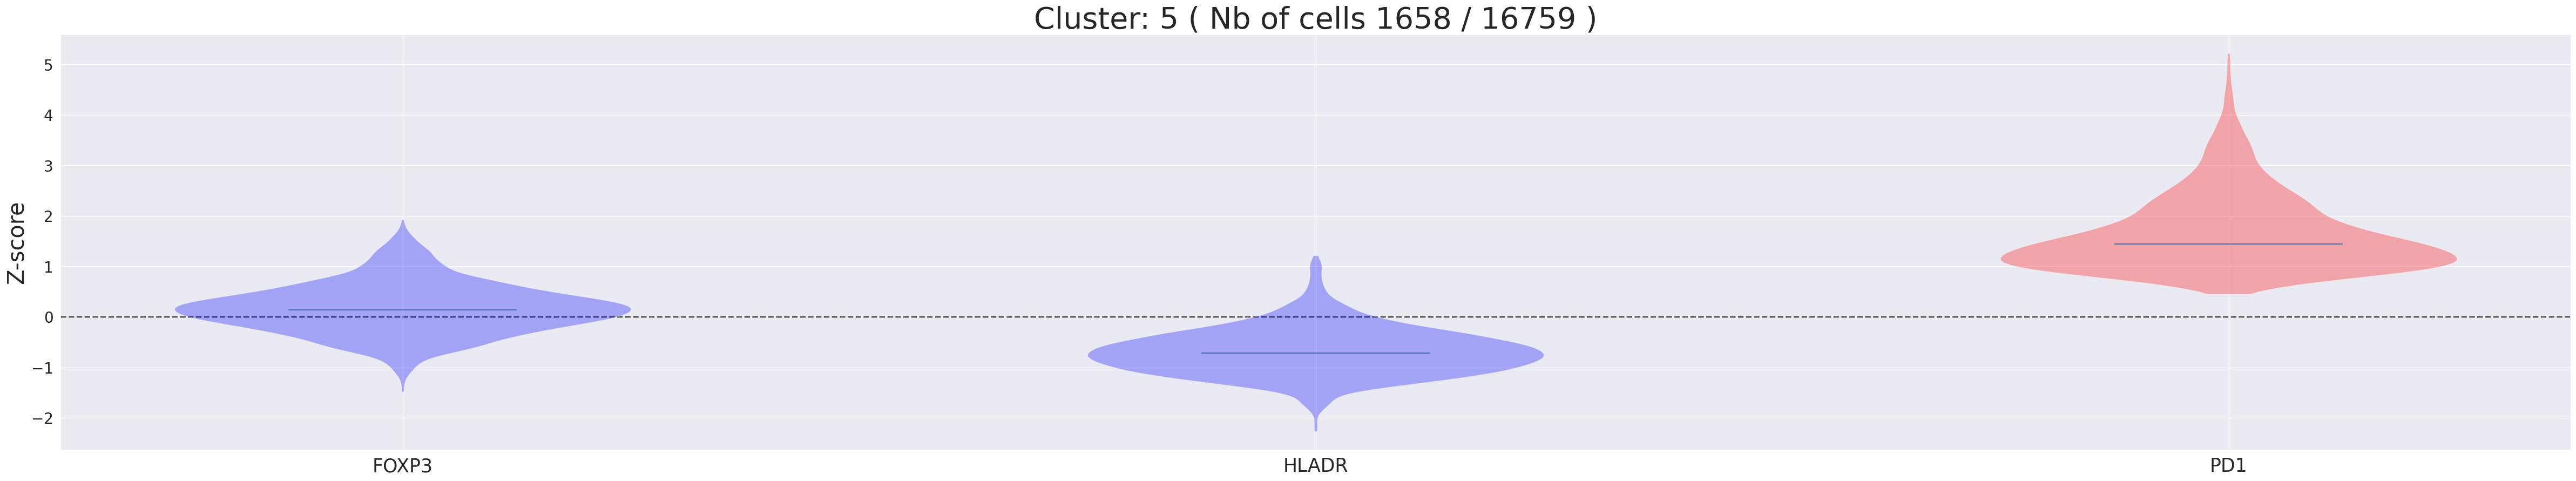

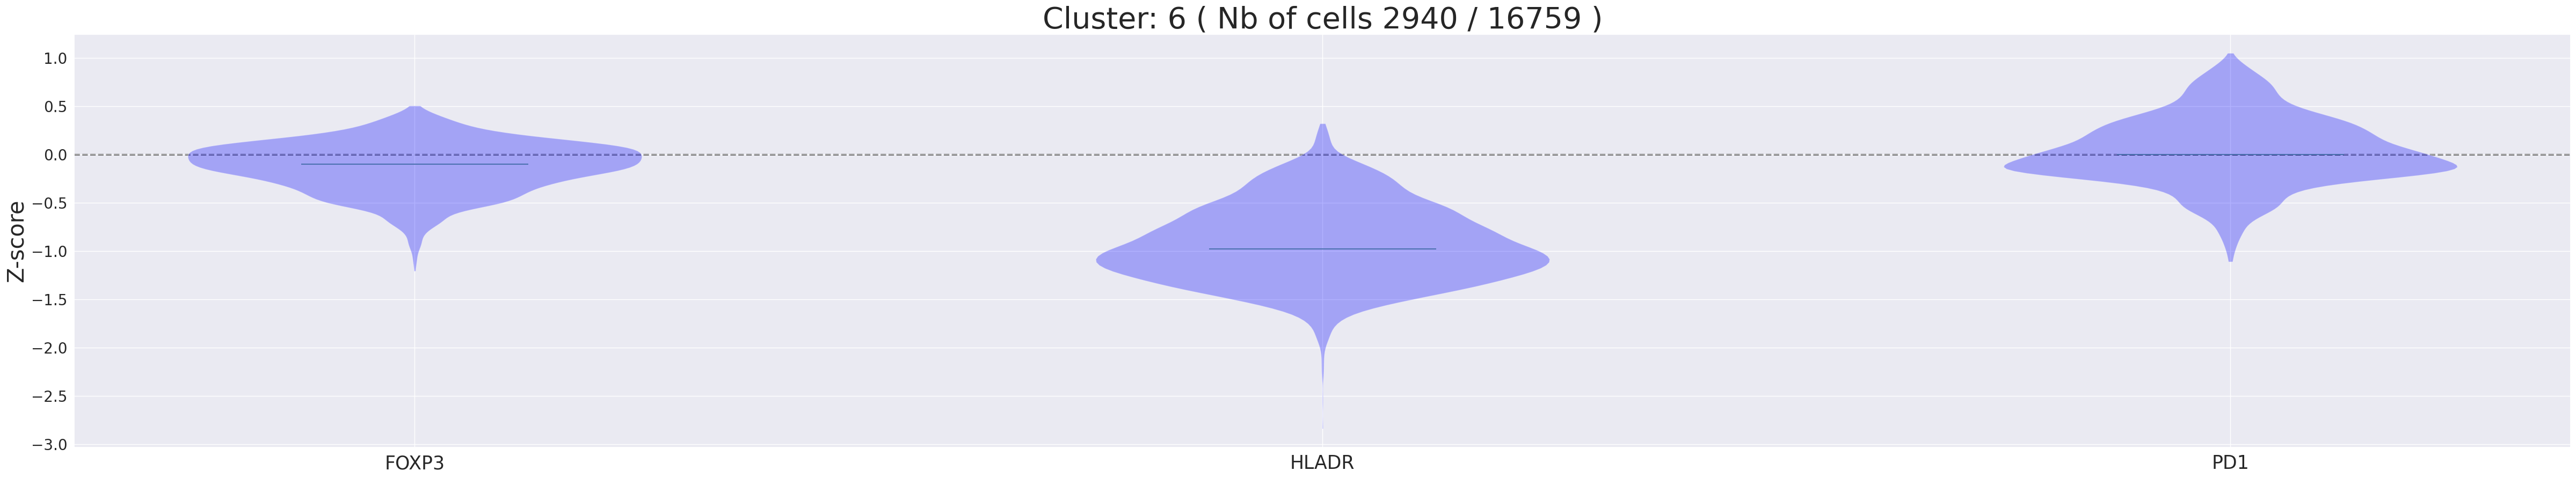

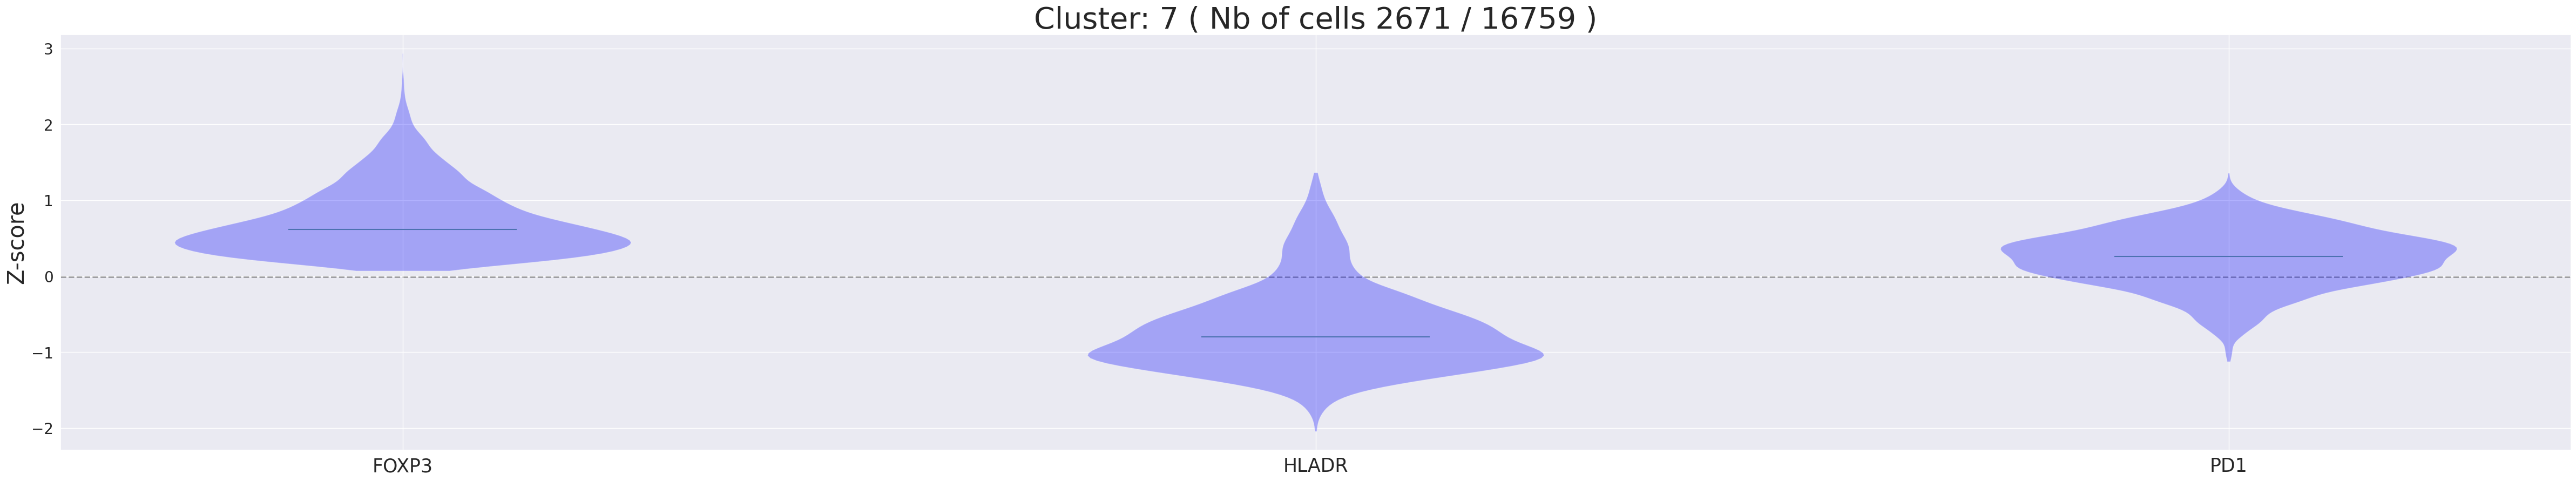

In [115]:
plot_mfi_cluster(df_subpop_cluster_marker,path_subpop+"plot_mfi_cluster/",thresh=1)


### 📊 **Representation of clusters on the biopsy**
⚠️ USER INPUT REQUIRED
*Image showing the clusters on the biopsies as well as the markers most present in these clusters in order to assess the consistency of the clustering*

#### 🛠️ Functions

In [92]:
def draw_outline(img, list_pixel, color=[255, 255, 0], width=1):
    # Convertir en RGB si image grayscale
    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    # Créer un masque binaire à partir de list_pixel
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    for pixel in list_pixel:
        x, y = map(int, pixel.split(","))
        if 0 <= x < mask.shape[0] and 0 <= y < mask.shape[1]:
            mask[x, y] = 255

    # Trouver les contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Dessiner les contours sur l'image
    img = cv2.drawContours(img, contours, -1, color, thickness=width)

    return img


#### ⚙️ Execution

In [119]:
processing=input("Enter 1 or 2 to choose the image processing used to display the clusters: ")

Enter 1 or 2 to choose the image processing used to display the clusters: 1


In [120]:
path_rep=path_subpop+"representation_cluster_roi/"
path_img=path+"images/img_processing_"+processing+"/Marker/"

if os.path.isdir(path_rep)==False:
  os.mkdir(path_rep)

In [121]:
df_mfi=pd.read_csv(path_subpop+"mfi_"+pheno+"_subpop_cluster.csv")
print(df_mfi.shape)
df_mfi.head()

(16759, 6)


,FOXP3,HLADR,PD1,ROI,label,cluster
0,2.138132,3.062035,1.497794,ROI,71,3
1,-0.378150,-0.685014,2.432714,ROI,112,5
2,-0.287683,-1.348972,-0.240394,ROI,164,4
3,0.068727,-0.936490,0.409420,ROI,165,6
4,0.441679,-0.485195,0.128908,ROI,169,7


In [122]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from skimage.segmentation import find_boundaries
from tqdm.auto import tqdm

# ======================================================
# Préparation clusters / marqueurs dominants
# ======================================================

df_cluster = df_mfi.drop(
    columns=[ "ROI","label"],
    errors="ignore"
)

df_cluster = df_cluster.groupby("cluster").mean()

df_max = df_cluster.idxmax(axis=1)

# enlever le premier max pour trouver le second
for cl in df_cluster.index:
    df_cluster.loc[cl, df_max.loc[cl]] = 0

df_max2 = df_cluster.idxmax(axis=1)

list_roi = df_mfi["ROI"].unique()

# ======================================================
# Fonctions utilitaires
# ======================================================

def read_gray(path):
    arr = np.array(Image.open(path))
    if arr.ndim > 2:
        arr = arr[..., 0]
    return arr.astype(np.float32)


def normalize_robust(arr, p_low=1, p_high=99.8):
    lo, hi = np.percentile(arr, [p_low, p_high])
    if hi <= lo:
        return np.zeros_like(arr, dtype=np.uint8)
    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / (hi - lo)
    return (arr * 255).astype(np.uint8)


def get_mask(path_mask_cell, roi):
    for ext in (".tif", ".tiff", ".png"):
        p = os.path.join(path_mask_cell, roi + ext)
        if os.path.isfile(p):
            return np.array(Image.open(p))
    return None


# ======================================================
# Boucle principale ROI × cluster
# ======================================================

for roi in tqdm(list_roi, desc="ROIs"):

    mask = get_mask(path_mask_cell, roi)
    if mask is None:
        continue

    if mask.ndim > 2:
        mask = mask[..., 0]

    mask = mask.astype(np.int32)

    for cluster in df_cluster.index:
        marker_max = df_max.loc[cluster]
        marker_max2 = df_max2.loc[cluster]

        out_dir = os.path.join(path_rep, str(cluster))
        os.makedirs(out_dir, exist_ok=True)

        # ======================
        # Chargement marqueurs
        # ======================

        img1 = read_gray(os.path.join(path_img, marker_max, roi + ".png"))
        img2 = read_gray(os.path.join(path_img, marker_max2, roi + ".png"))

        img1 = normalize_robust(img1)
        img2 = normalize_robust(img2)

        img_rgb = np.zeros((*img1.shape, 3), dtype=np.uint8)
        img_rgb[..., 0] = img1
        img_rgb[..., 1] = img2

        # ======================
        # Sélection labels du cluster
        # ======================

        labels_cluster = df_mfi.loc[
            (df_mfi["ROI"] == roi) & (df_mfi["cluster"] == cluster),
            "label"
        ].astype(int).unique()

        if len(labels_cluster) == 0:
            continue

        # ======================
        # Contours COMPLETS
        # ======================

        mask_sel = np.where(np.isin(mask, labels_cluster), mask, 0)
        boundaries = find_boundaries(mask_sel, mode="outer")

        # épaissir contours
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        boundaries = cv2.dilate(boundaries.astype(np.uint8), kernel) > 0

        # ======================
        # Dessin
        # ======================

        img_rgb[boundaries] = [255, 255, 255]

        # image binaire cluster (QC)
        img_cluster = (mask_sel > 0).astype(np.uint8) * 255

        # ======================
        # Figure
        # ======================

        plt.figure(figsize=(16, 8))

        plt.subplot(1, 4, 1)
        plt.title(f"Cluster {cluster}")
        plt.imshow(img_cluster, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.title(f"Red: {marker_max} | Green: {marker_max2}")
        plt.imshow(img_rgb)
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.title(marker_max)
        plt.imshow(img1, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.title(marker_max2)
        plt.imshow(img2, cmap="gray")
        plt.axis("off")

        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, roi + ".png"),
                    dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close()


ROIs:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb

### 📊 **Display clusters on the dimensionality reduction**
*Dimensional reduction is performed on the MFI of each cell, and then the clusters of different colors are displayed on them to verify the clustering consistency.*

#### Functions

In [ ]:

def plot_pacmap(df_pacmap,feature, figsize=(8, 6), savepath=None,title=""):
    # Order phenotypes by frequency (optional but nice for legend)
    pheno_counts = df_pacmap[feature].value_counts()
    phenotypes = pheno_counts.index.tolist()

    # Palette with as many distinct colors as phenotypes
    palette = sns.color_palette("tab20", n_colors=len(phenotypes))
    pheno_to_color = {ph: palette[i] for i, ph in enumerate(phenotypes)}

    plt.figure(figsize=figsize)
    ax = plt.gca()

    # Plot phenotype by phenotype (gives more control than seaborn.scatterplot)
    for ph in phenotypes:
        sub = df_pacmap[df_pacmap[feature] == ph]
        ax.scatter(
            sub['0'],
            sub['1'],
            s=8,
            color=pheno_to_color[ph],
            alpha=0.7,
            edgecolor="none",
            label=f"{ph} (n={len(sub)})"
        )

    ax.set_xlabel("PaCMAP 1", fontsize=11)
    ax.set_ylabel("PaCMAP 2", fontsize=11)
    ax.set_title(title, fontsize=13, pad=10)

    # Legend outside the plot
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=9,
        markerscale=4.0,
        title=feature
    )

    # Remove top/right spines for a cleaner look
    sns.despine(ax=ax)

    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"✅ The graph can be found there:  {savepath}")

    plt.show()




#### Execution

In [ ]:
path_reduc=path_subpop+"reduction_dimension/"
if os.path.isdir(path_reduc)==False:
  os.mkdir(path_reduc)

In [ ]:
df_subpop_cluster=pd.read_csv(path_subpop+"mfi_"+pheno+"_subpop_cluster.csv")
df_subpop_cluster_marker=df_subpop_cluster.drop(["label","ROI"],axis=1)

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_subpop_cluster_marker)

pacmap = PaCMAP(n_components=2, random_state=0)
X_2d = pacmap.fit_transform(X_scaled, init="pca")
df_pacmap=pd.DataFrame(X_2d,columns=["0","1"])
df_pacmap.to_csv(path_subpop+"pacmap_reduction_pheno_"+pheno+".csv")
df_pacmap["cluster"]=list(df_subpop_cluster["cluster"])

✅ The graph can be found there:  /content/gdrive/MyDrive/these/pipeline/rejection/clustering/LT4/reduction_dimension/Pacmap_clusters


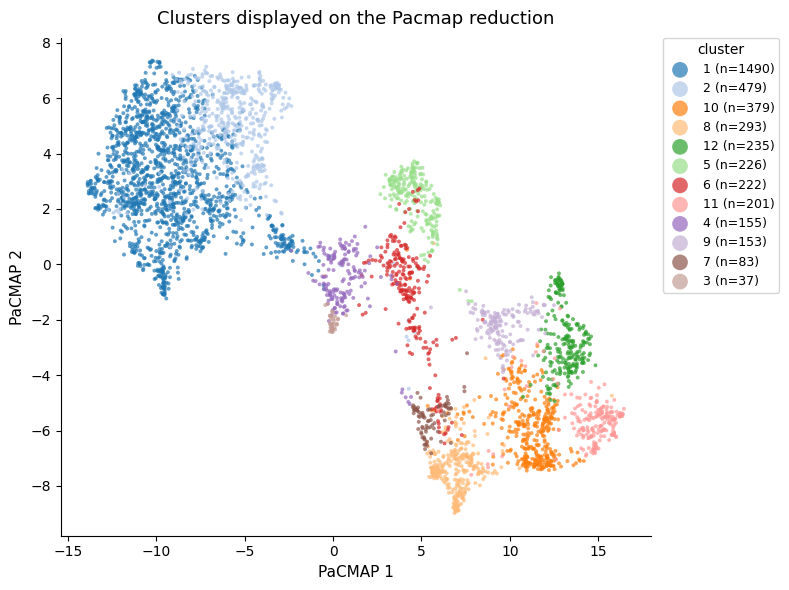

In [ ]:
plot_pacmap(df_pacmap,"cluster", savepath=path_reduc+"Pacmap_clusters",title="Clusters displayed on the Pacmap reduction")


In [ ]:
path_reduc_cluster=path_reduc+"clusters/"
if os.path.isdir(path_reduc_cluster)==False:
  os.mkdir(path_reduc_cluster)

In [ ]:

labels_km = list(df_pacmap["cluster"])

for cluster in df_pacmap["cluster"].unique():
    # Work on a copy
    df = df_pacmap.copy()

    # Create a new column used for coloring:
    # current cluster = its ID, others = "other"
    df["cluster_display"] = np.where(
        df["cluster"] == cluster,
        str(cluster),
        "other"
    )

    savepath = os.path.join(
        path_reduc_cluster,
        f"cluster_{cluster}.png"
    )

    plot_pacmap(
        df,
        "cluster_display",
        savepath=savepath,
        title=f"Cluster {cluster} displayed on the PaCMAP reduction"
    )



Output hidden; open in https://colab.research.google.com to view.

### ⚙️ **Phenotypes annotation**
*Annotation of clusters using MFI graphs, dimensionality reductions, heatmaps, and cluster representations on biopsies*  
⚠️ USER INPUT REQUIRED


#### 🛠️ Functions

In [123]:
def plot_mfi_cluster(df_mfi,cluster,list_marker):
    df_mfi = df_mfi[df_mfi["cluster"] == cluster]
    nb_cell=len(df_mfi.loc[df_mfi.loc[:,"cluster"]==cluster])
    nb_tot=df_mfi.shape[0]
    list_col=[]
    list_data=[]
    for m in list_marker:
       list_m=list(df_mfi.loc[df_mfi.loc[:,"cluster"]==cluster][m])
       list_data.append(list_m)
    for i in range(len(list_data)):
       if np.mean(list_data[i])>1.5:
        list_col.append("red")
       else:
        list_col.append("blue")
    pos=[float(p) for p in range(0,len(list_data))]
    fig,ax = plt.subplots(1,1,figsize=(60,10))
    violin=ax.violinplot(list_data,pos,showextrema=False,showmedians=True)
    c=0
    for pc in violin['bodies']:
       pc.set_facecolor(list_col[c])
       c+=1
    ax.set_title("Cluster: "+str(cluster)+" ( Nb of cells "+str(nb_cell)+" / "+str(nb_tot)+" )",fontsize=40)
    ax.set_xticks(np.arange(0,len(list_marker)),list_marker,size=25)
    ax.tick_params(axis='y', labelsize=20)
    plt.ylabel("Z-score",size=30)
    plt.show()


In [127]:
from IPython.display import clear_output

def plot_mfi_cluster(df_mfi,cluster,list_marker):
    df_mfi = df_mfi[df_mfi["cluster"] == cluster]
    nb_cell=len(df_mfi.loc[df_mfi.loc[:,"cluster"]==cluster])
    nb_tot=df_mfi.shape[0]
    list_col=[]
    list_data=[]
    for m in list_marker:
       list_m=list(df_mfi.loc[df_mfi.loc[:,"cluster"]==cluster][m])
       list_data.append(list_m)
    for i in range(len(list_data)):
       if np.mean(list_data[i])>1.5:
        list_col.append("red")
       else:
        list_col.append("blue")
    pos=[float(p) for p in range(0,len(list_data))]
    fig,ax = plt.subplots(1,1,figsize=(60,10))
    violin=ax.violinplot(list_data,pos,showextrema=False,showmedians=True)
    c=0
    for pc in violin['bodies']:
       pc.set_facecolor(list_col[c])
       c+=1
    ax.set_title("Cluster: "+str(cluster)+" ( Nb of cells "+str(nb_cell)+" / "+str(nb_tot)+" )",fontsize=40)
    ax.set_xticks(np.arange(0,len(list_marker)),list_marker,size=25)
    ax.tick_params(axis='y', labelsize=20)
    plt.ylabel("Z-score",size=30)
    plt.show()

def plot_cluster_profile(df_mfi, cluster, marker_cols):
    sub = df_mfi[df_mfi["cluster"] == cluster]

    # résumé robuste : médiane par marqueur
    med = sub[marker_cols].median().sort_values(ascending=False)

    plt.figure(figsize=(8, 3.5))
    plt.plot(med.values, marker="o")
    plt.xticks(range(len(med.index)), med.index, rotation=45, ha="right")
    plt.ylabel("Median intensity (MFI)")
    plt.title(f"Cluster {cluster} | n={len(sub)}")
    plt.tight_layout()
    plt.show()
def annotate_clusters_with_plots(df_mfi, marker_cols, phenotype_list=None):
    clusters = sorted(df_mfi["cluster"].unique())
    dict_pheno_cluster = {}

    # liste de phénotypes proposée
    if phenotype_list is None:
        phenotype_list = ["Epithelium", "Stromal", "LT4", "LT8", "LB", "Mono|Macro", "Neutrophiles", "Endothelium"]

    pheno_dropdown = widgets.Dropdown(
        options=phenotype_list,
        description="Phenotype:",
        layout=widgets.Layout(width="400px")
    )

    next_btn = widgets.Button(description="✅ Save & Next", button_style="success")
    skip_btn = widgets.Button(description="⏭ Skip", button_style="")
    out = widgets.Output()

    state = {"i": 0}

    def render():
        clear_output(wait=True)
        display(pheno_dropdown, widgets.HBox([next_btn, skip_btn]), out)

        out.clear_output(wait=True)
        with out:
            if state["i"] >= len(clusters):
                print("✅ Annotation finished.")
                print("\nResult dict_pheno_cluster:")
                for k in sorted(dict_pheno_cluster.keys()):
                    print(f"- {k}: {sorted(dict_pheno_cluster[k])}")
                return

            cluster = clusters[state["i"]]
            print(f"Cluster {cluster} ({state['i']+1}/{len(clusters)})")
            plot_mfi_cluster(df_mfi, cluster, marker_cols)

    def on_next(_):
        if state["i"] >= len(clusters):
            return

        cluster = clusters[state["i"]]
        pheno = pheno_dropdown.value

        dict_pheno_cluster.setdefault(pheno, []).append(cluster)
        state["i"] += 1
        render()

    def on_skip(_):
        state["i"] += 1
        render()

    next_btn.on_click(on_next)
    skip_btn.on_click(on_skip)

    render()
    return dict_pheno_cluster

#### Execution

In [125]:
df_subpop_cluster=pd.read_csv(path_subpop+"mfi_"+pheno+"_subpop_cluster.csv")

In [130]:
marker_cols = df_mfi.drop(["ROI","label","cluster"],axis=1).columns
list_pheno=input("Enter the different phenotypes you are excepted (separated by a comma): ").split(",")
dict_pheno_cluster = annotate_clusters_with_plots(df_mfi, marker_cols,phenotype_list=list_pheno)


Dropdown(description='Phenotype:', layout=Layout(width='400px'), options=('FOXP3', 'HLADR', 'PD1', 'No'), valu…

Output()

In [131]:
dict_cluster_pheno={}
for k in dict_pheno_cluster.keys():
  for v in dict_pheno_cluster[k]:
    if v not in dict_cluster_pheno.keys():
     dict_cluster_pheno[v]=k

In [133]:
df_mfi["phenotype"]=[dict_cluster_pheno[cluster] for cluster in df_mfi["cluster"]]
df_mfi.to_csv(path_subpop+"df_"+pheno+"_subpopulations.csv")
print(f"✅ The dataframe with the clusters of {pheno} subpopulations can be found in the following folder:{path_subpop}df_{pheno}_subpopulations.csv")
print(df_mfi.shape)
df_mfi.head()

✅ The dataframe with the clusters of LT4 subpopulations can be found in the following folder:/content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/df_LT4_subpopulations.csv
(16759, 7)


,FOXP3,HLADR,PD1,ROI,label,cluster,phenotype
0,2.138132,3.062035,1.497794,ROI,71,3,HLADR
1,-0.378150,-0.685014,2.432714,ROI,112,5,PD1
2,-0.287683,-1.348972,-0.240394,ROI,164,4,No
3,0.068727,-0.936490,0.409420,ROI,165,6,No
4,0.441679,-0.485195,0.128908,ROI,169,7,FOXP3


### 📊 **Reduction of dimension on the cell with a defined phenotype**
⚠️ USER INPUT REQUIRED  
*Dimensional reduction performed on the MFI of cells with a phenotype to evaluate the annotation of phenotypes*

#### ⚙️ Functions

In [134]:
%pip install pacmap
import pacmap

In [135]:
def choose_colors_interactive(df_pheno, default_palette="tab10"):
    phenotypes = sorted(df_pheno["phenotype"].unique())
    pickers = {}
    dico_color = {}

    print("🎨 Choose a color for each phenotype:")

    for pheno in phenotypes:
        picker = widgets.ColorPicker(
            description=pheno,
            value="#1f77b4",  # couleur initiale (bleu matplotlib)
            layout=widgets.Layout(width="300px")
        )
        pickers[pheno] = picker
        display(picker)

    confirm = widgets.Button(description="✅ Confirm colors")

    def on_confirm(b):
        for ph, picker in pickers.items():
            dico_color[ph] = picker.value
        print("✔ Colors selected:")
        for k, v in dico_color.items():
            print(f"{k}: {v}")

    confirm.on_click(on_confirm)
    display(confirm)

    return dico_color


In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgb

def plot_pacmap(
    df_pacmap,
    feature,
    figsize=(8, 6),
    savepath=None,
    title="",
    dico_color=None,
):
    """
    Plot PaCMAP colored by phenotype with optional user-defined colors.

    Parameters
    ----------
    df_pacmap : pd.DataFrame
        DataFrame containing PaCMAP coordinates ('0','1') and phenotype column
    feature : str
        Column name used for coloring (e.g. 'phenotype')
    dico_color : dict or None
        Mapping {phenotype: color}, where color can be hex, RGB tuple, or CSS name
    """

    # Order phenotypes by frequency (nicer legend)
    pheno_counts = df_pacmap[feature].value_counts()
    phenotypes = pheno_counts.index.tolist()

    # Base palette (fallback)
    fallback_palette = sns.color_palette("tab20", n_colors=len(phenotypes))

    pheno_to_color = {}

    for i, ph in enumerate(phenotypes):
        if dico_color is not None and ph in dico_color:
            try:
                # Convert hex / name / rgb -> RGB tuple
                pheno_to_color[ph] = to_rgb(dico_color[ph])
            except ValueError:
                raise ValueError(f"❌ Invalid color for phenotype '{ph}': {dico_color[ph]}")
        else:
            pheno_to_color[ph] = fallback_palette[i]

    # ---------------- Plot ----------------
    plt.figure(figsize=figsize)
    ax = plt.gca()

    for ph in phenotypes:
        sub = df_pacmap[df_pacmap[feature] == ph]
        ax.scatter(
            sub["0"],
            sub["1"],
            s=5,
            color=pheno_to_color[ph],
            alpha=0.7,
            edgecolor="none",
            label=f"{ph} (n={len(sub)})",
        )

    ax.set_xlabel("PaCMAP 1", fontsize=11)
    ax.set_ylabel("PaCMAP 2", fontsize=11)
    ax.set_title(title, fontsize=13, pad=10)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=9,
        markerscale=4.0,
        title=feature,
    )

    sns.despine(ax=ax)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"✅ The graph can be found there: {savepath}")

    plt.show()


In [137]:
def display_reduction_marker(reduced_vector,marker,size_picture,path,title,subtitle,min,max):

  plt.figure(figsize=size_picture)
  plt.title(title+subtitle,fontsize=40)
  plt.scatter(reduced_vector[:,0],reduced_vector[:,1],c=marker,s=0.5,label=subtitle,vmin=min,vmax=max)
  plt.axis('off')
  plt.colorbar(label=subtitle)
  plt.legend(fontsize=20)
  plt.savefig(path+title+"_"+subtitle+".png")
  print("✅ The graph can be found there:  "+path+title+"_"+subtitle+".png")
  plt.show()

#### 🛠️ Execution

In [149]:
path_reduc=path_subpop+"reduction_dimension/"
path_reduc_marker=path_reduc+"markers/"
if os.path.isdir(path_reduc)==False:
  os.mkdir(path_reduc)
if os.path.isdir(path_reduc_marker)==False:
  os.mkdir(path_reduc_marker)

In [145]:
df_pheno=pd.read_csv(path_subpop+"df_"+pheno+"_subpopulations.csv")
df_pheno.head()

,Unnamed: 0,FOXP3,HLADR,PD1,ROI,label,cluster,phenotype
0,0,2.138132,3.062035,1.497794,ROI,71,3,HLADR
1,1,-0.378150,-0.685014,2.432714,ROI,112,5,PD1
2,2,-0.287683,-1.348972,-0.240394,ROI,164,4,No
3,3,0.068727,-0.936490,0.409420,ROI,165,6,No
4,4,0.441679,-0.485195,0.128908,ROI,169,7,FOXP3


In [146]:
df_pheno=df_pheno.drop(["ROI","label","cluster","Unnamed: 0"],axis=1)

# Dynamically get the list of all marker columns from the cleaned df_pheno
all_marker_columns = df_pheno.columns.drop("phenotype").tolist()

df_umap=df_pheno.copy()
# Use the correct list of all marker columns for dimensionality reduction
df_umap=df_umap[all_marker_columns]
df_umap["phenotype"]=df_pheno["phenotype"]
df_umap=df_umap.loc[df_umap.loc[:,"phenotype"]!="No"]
print(df_umap.shape)
list_pheno=list(df_umap["phenotype"])
df_pacmap=df_umap.drop(["phenotype"],axis=1)

embedding = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0)
X_transformed = embedding.fit_transform(df_pacmap, init="pca")

df_pacmap=pd.DataFrame(X_transformed,columns=["0","1"])
df_pacmap["phenotype"]=list_pheno
df_pacmap.to_csv(path_clust+"pacmap_reduction_pheno.csv")
print(df_pacmap.shape)
df_pacmap.head()

(9268, 4)
(9268, 3)


,0,1,phenotype
0,5.582065,8.934897,HLADR
1,-15.171649,11.428424,PD1
2,-4.847884,-4.178164,FOXP3
3,-2.085122,-5.541422,FOXP3
4,-3.186566,-5.583712,FOXP3


In [142]:
dico_color = choose_colors_interactive(df_pacmap)

🎨 Choose a color for each phenotype:


ColorPicker(value='#1f77b4', description='FOXP3', layout=Layout(width='300px'))

ColorPicker(value='#1f77b4', description='HLADR', layout=Layout(width='300px'))

ColorPicker(value='#1f77b4', description='PD1', layout=Layout(width='300px'))

Button(description='✅ Confirm colors', style=ButtonStyle())

✔ Colors selected:
FOXP3: #00ff1e
HLADR: #fe71fa
PD1: #fff700


✅ The graph can be found there: /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/reduction_dimension/pacmap_phenotype.png


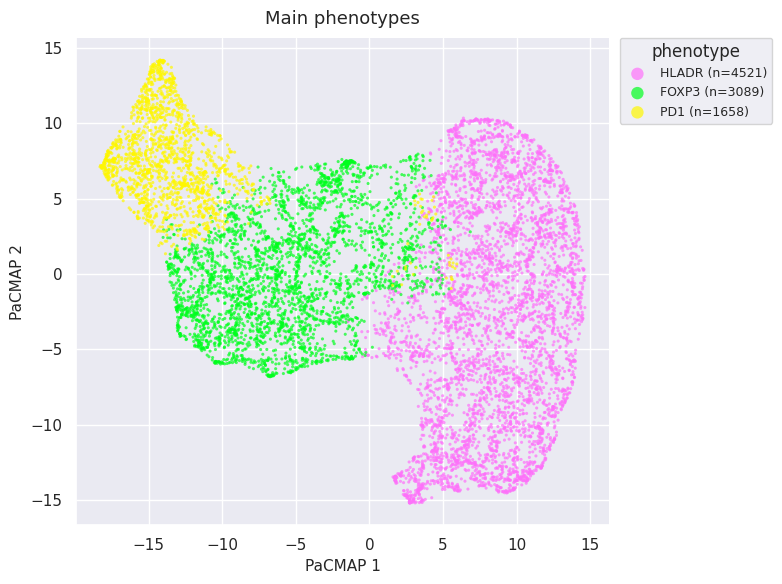

In [147]:
plot_pacmap(df_pacmap, "phenotype",savepath=path_reduc + "pacmap_phenotype.png",title="Main phenotypes",dico_color=dico_color)

✅ The graph can be found there:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/reduction_dimension/markers/PacMap__FOXP3.png


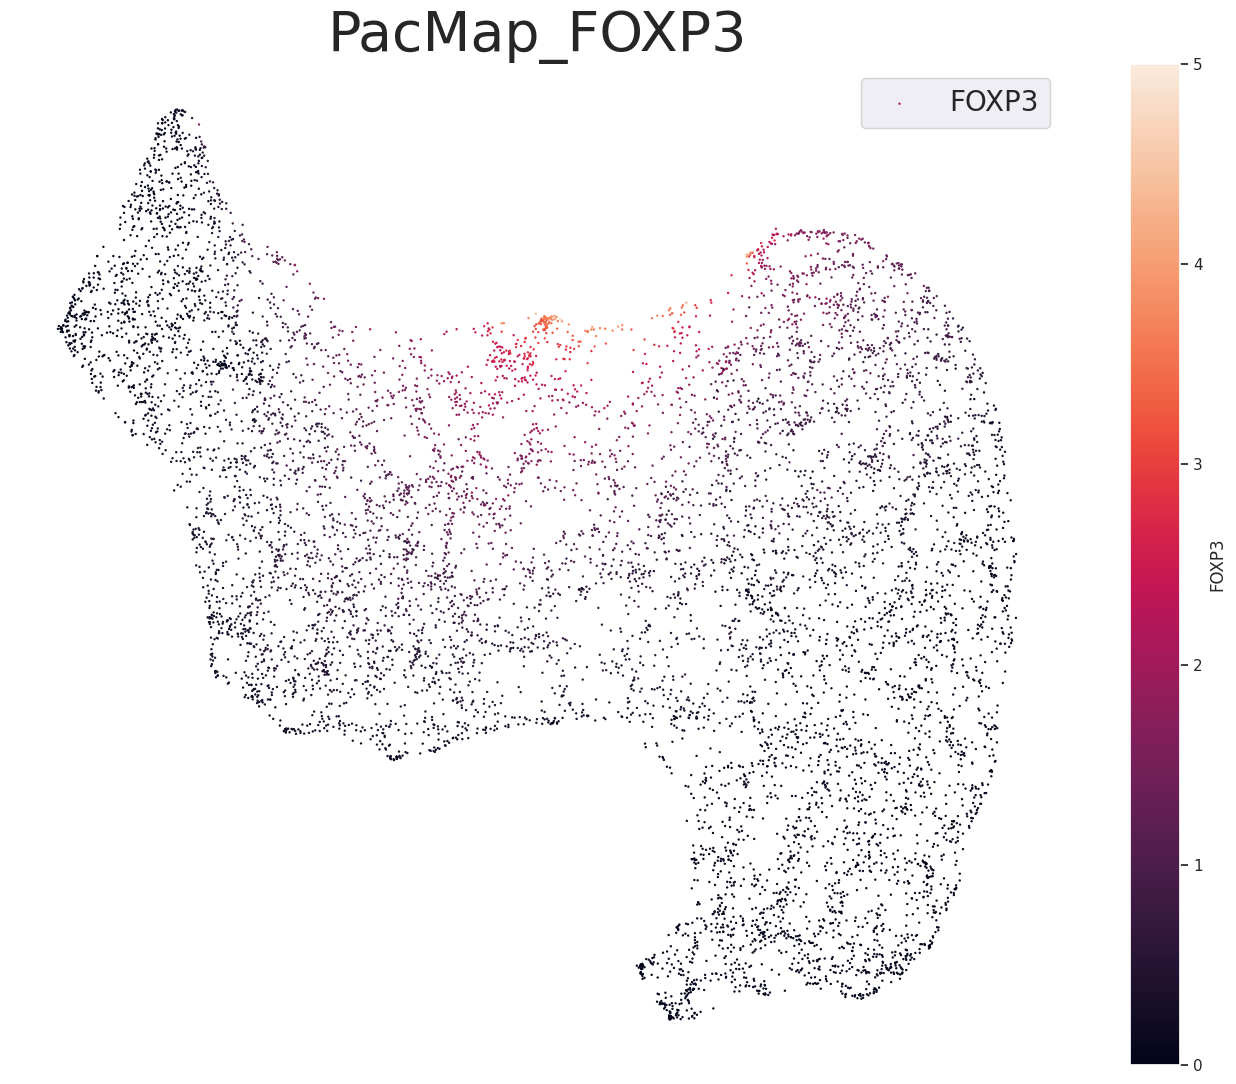

✅ The graph can be found there:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/reduction_dimension/markers/PacMap__HLADR.png


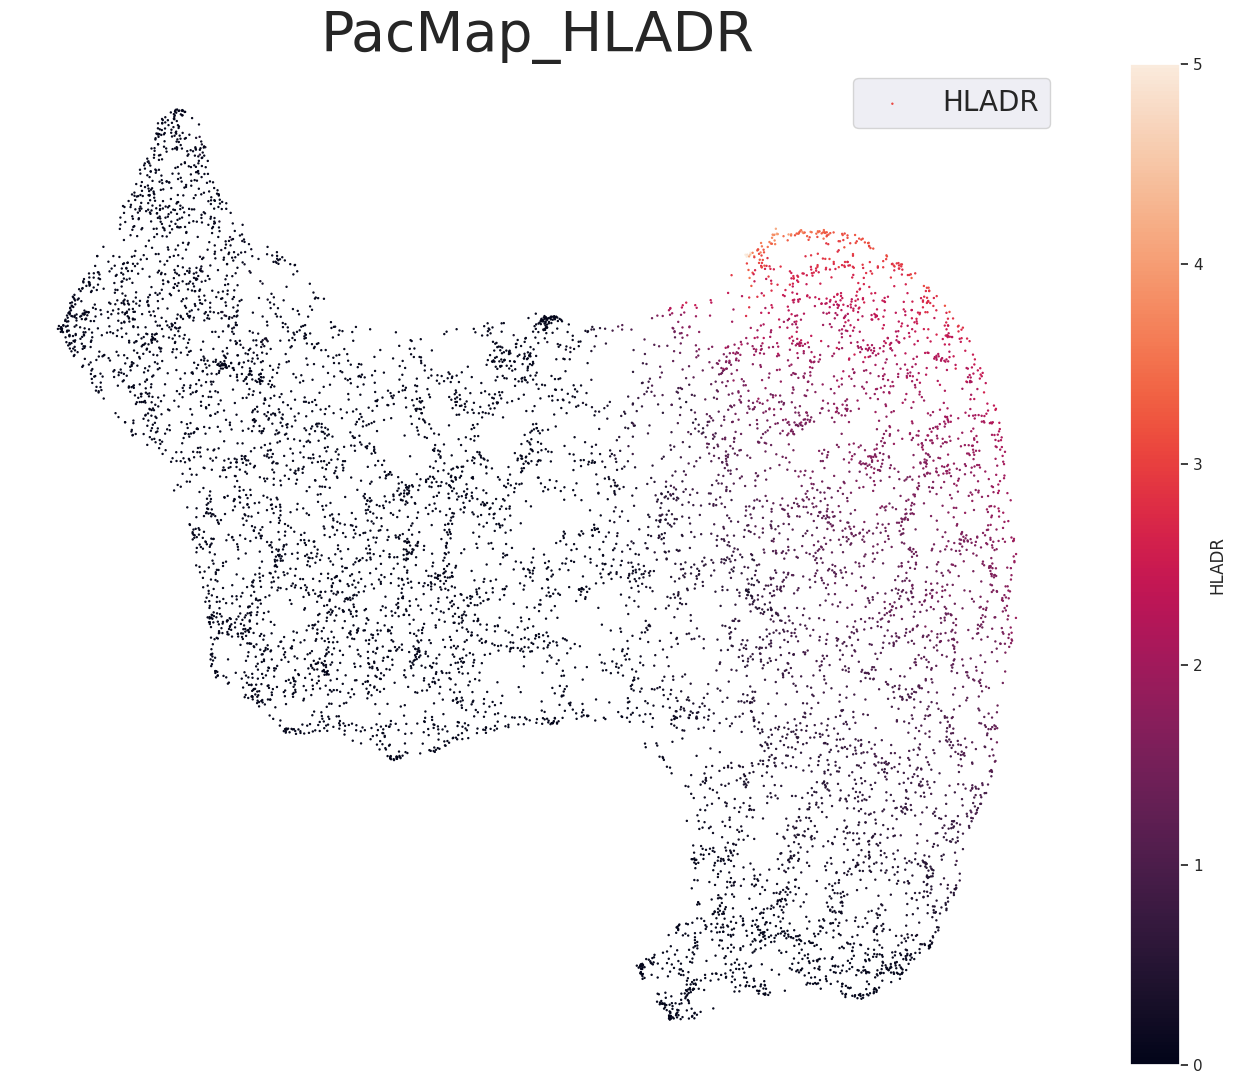

✅ The graph can be found there:  /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/reduction_dimension/markers/PacMap__PD1.png


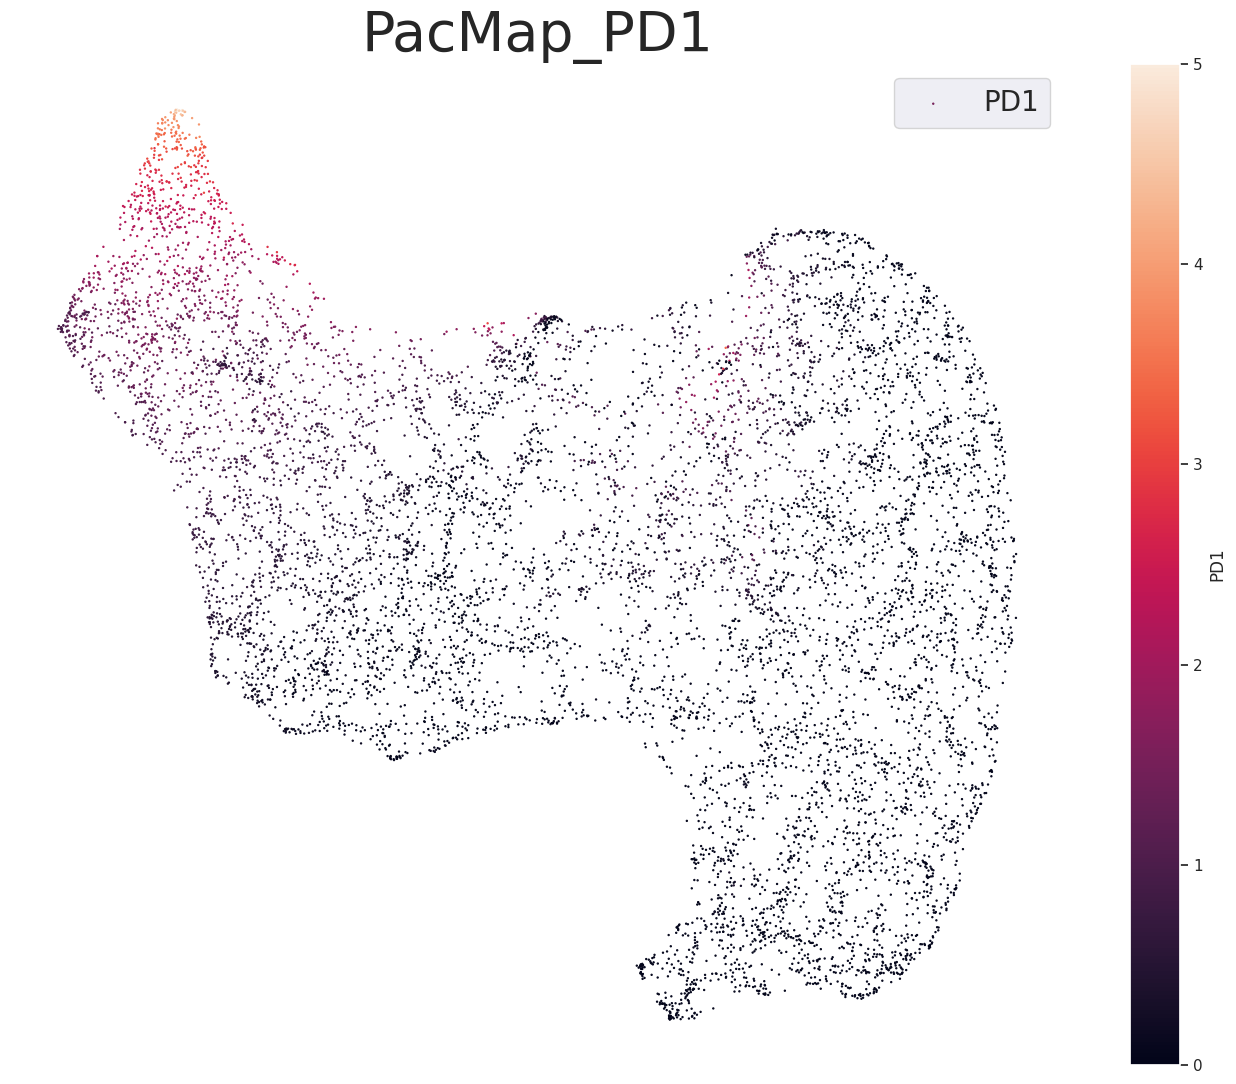

In [150]:
df_mfi=df_pheno.copy()
df_mfi=df_mfi[df_mfi["phenotype"]!="No"]
df_mfi=df_mfi.drop(["phenotype"],axis=1)
pacmap_embeded=np.array(df_pacmap)
for marker in df_mfi.columns:
 list_marker=list(df_mfi[marker])
 display_reduction_marker(pacmap_embeded,list_marker,(17,13),path_reduc_marker,"PacMap_",marker,0,5)

### 📊 **Display the colored mask of the cells on the biopsies**
⚠️ USER INPUT REQUIRED  
*Image of biopsies with the mask of cells stained according to their phenotype*

In [151]:
path_subpop_pheno=path_subpop+"images_phenotype/"
if os.path.isdir(path_subpop_pheno)==False:
  os.mkdir(path_subpop_pheno)

In [152]:
df_pheno=pd.read_csv(path_subpop+"df_"+pheno+"_subpopulations.csv")
df_pheno=df_pheno[df_pheno["phenotype"]!="No"]
df_pheno.head()

,Unnamed: 0,FOXP3,HLADR,PD1,ROI,label,cluster,phenotype
0,0,2.138132,3.062035,1.497794,ROI,71,3,HLADR
1,1,-0.378150,-0.685014,2.432714,ROI,112,5,PD1
4,4,0.441679,-0.485195,0.128908,ROI,169,7,FOXP3
5,5,0.280731,-0.324971,0.007269,ROI,203,7,FOXP3
6,6,0.298346,-0.410829,-0.150792,ROI,214,7,FOXP3


#### 🛠️ Functions

In [154]:
def choose_colors_interactive(df_pheno, default_palette="tab10"):
    phenotypes = sorted(df_pheno["phenotype"].unique())
    pickers = {}
    dico_color = {}

    print("🎨 Choose a color for each phenotype:")

    for pheno in phenotypes:
        picker = widgets.ColorPicker(
            description=pheno,
            value="#1f77b4",  # couleur initiale (bleu matplotlib)
            layout=widgets.Layout(width="300px")
        )
        pickers[pheno] = picker
        display(picker)

    confirm = widgets.Button(description="✅ Confirm colors")

    def on_confirm(b):
        for ph, picker in pickers.items():
            dico_color[ph] = picker.value
        print("✔ Colors selected:")
        for k, v in dico_color.items():
            print(f"{k}: {v}")

    confirm.on_click(on_confirm)
    display(confirm)

    return dico_color


In [155]:
# ======================================================
# FULL SCRIPT — Cell phenotype visualization from masks
# ======================================================

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb
from io import BytesIO

# ==============================
# Global parameters
# ==============================

LABEL_COL = "label"
IMG_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff")

# ==============================
# Color mapping
# ==============================

def build_color_mapping(df, custom_colors=None):
    phenotypes = df["phenotype"].unique()
    pheno_to_color = {}

    if custom_colors:
        for ph in phenotypes:
            if ph in custom_colors:
                r, g, b = to_rgb(custom_colors[ph])
                pheno_to_color[ph] = (int(r*255), int(g*255), int(b*255))
            else:
                pheno_to_color[ph] = (255, 255, 255)
    else:
        cmap = plt.get_cmap("tab10", len(phenotypes))
        for i, ph in enumerate(phenotypes):
            r, g, b, _ = cmap(i)
            pheno_to_color[ph] = (int(r*255), int(g*255), int(b*255))

    return pheno_to_color


# ==============================
# Robust image reading
# ==============================

def read_as_gray_uint8(path):
    arr = np.array(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]

    if arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        mn, mx = arr.min(), arr.max()
        if mx > mn:
            arr = (arr - mn) / (mx - mn) * 255
        else:
            arr[:] = 0
        arr = arr.astype(np.uint8)

    return arr


# ==============================
# File discovery helpers
# ==============================

def find_first_image(path_img, roi):
    roi_dir = os.path.join(path_img, roi)
    if not os.path.isdir(roi_dir):
        return None
    files = sorted(f for f in os.listdir(roi_dir) if f.lower().endswith(IMG_EXTS))
    return os.path.join(roi_dir, files[0]) if files else None


def find_mask(path_mask, roi):
    for ext in IMG_EXTS:
        p = os.path.join(path_mask, roi + ext)
        if os.path.isfile(p):
            return p
    return None


# ==============================
# Colorization from label mask
# ==============================

def colorize_from_mask(mask, df_roi, pheno_to_color):
    mask = mask.astype(np.int64)
    max_lab = int(mask.max())
    lut = np.zeros((max_lab + 1, 3), dtype=np.uint8)

    for lab, ph in zip(df_roi[LABEL_COL].astype(int), df_roi["phenotype"]):
        if lab <= max_lab and ph in pheno_to_color:
            lut[lab] = pheno_to_color[ph]

    return lut[mask]


# ==============================
# Adaptive legend (large biopsies)
# ==============================

def create_legend_image(
    pheno_to_color,
    image_height_px,
    dpi=200,
    height_fraction=0.35,   # fraction de la hauteur de l'image
    min_fontsize=18,
    max_fontsize=60,
):
    """
    Légende conçue pour très grandes images.
    - La légende occupe une fraction fixe de la hauteur de l'image
    - Le texte reste lisible même pour des images > 20k px
    """

    n_items = len(pheno_to_color)

    # --- hauteur cible de la légende en pouces ---
    target_height_px = image_height_px * height_fraction
    legend_height_in = target_height_px / dpi

    # --- taille de police proportionnelle ---
    fontsize = int(target_height_px / (n_items * 2.2))
    fontsize = max(min_fontsize, min(max_fontsize, fontsize))

    # --- nombre de colonnes si beaucoup de phénotypes ---
    ncol = 1
    if n_items > 10:
        ncol = 2
    if n_items > 20:
        ncol = 3

    # --- largeur proportionnelle ---
    legend_width_in = max(4.0, ncol * fontsize / 4)

    patches = [
        mpatches.Patch(color=np.array(c) / 255.0, label=str(ph))
        for ph, c in pheno_to_color.items()
    ]

    fig, ax = plt.subplots(
        figsize=(legend_width_in, legend_height_in),
        dpi=dpi
    )
    ax.axis("off")

    fig.legend(
        handles=patches,
        loc="upper left",
        fontsize=fontsize,
        title="Phenotypes",
        title_fontsize=fontsize + 6,
        frameon=False,
        ncol=ncol,
        handlelength=1.6,
        labelspacing=1.2,
        columnspacing=1.8,
    )

    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0.3)
    plt.close(fig)
    buf.seek(0)

    return Image.open(buf).convert("RGB")



def attach_legend(base_img, legend_img, padding=20):
    bw, bh = base_img.size
    lw, lh = legend_img.size

    out = Image.new("RGB", (bw + lw + padding, max(bh, lh)), (255, 255, 255))
    out.paste(base_img, (0, 0))
    out.paste(legend_img, (bw + padding, 0))
    return out


# ==============================
# Main function
# ==============================

def draw_cells_for_roi(
    df_roi,
    roi,
    path_img,
    path_mask,
    custom_colors=None,
    output_dir=None,
    image_ext=".png",
    show=True,
    save=True,
    mode="blend",      # "overwrite" or "blend"
    blend_alpha=0.65,
):
    pheno_to_color = build_color_mapping(df_roi, custom_colors)

    img_path = find_first_image(path_img, roi)
    if img_path is None:
        raise FileNotFoundError(f"No image found for ROI {roi}")

    base_gray = read_as_gray_uint8(img_path)
    H, W = base_gray.shape

    base_rgb = np.zeros((H, W, 3), dtype=np.uint8)
    mask_path = find_mask(path_mask, roi)
    if mask_path is None:
        raise FileNotFoundError(f"No mask found for ROI {roi}")

    mask = np.array(Image.open(mask_path))
    if mask.ndim > 2:
        mask = mask[..., 0]

    H2, W2 = min(H, mask.shape[0]), min(W, mask.shape[1])
    base_rgb = base_rgb[:H2, :W2]
    mask = mask[:H2, :W2]

    colored = colorize_from_mask(mask, df_roi, pheno_to_color)
    out = base_rgb.copy()
    fg = mask > 0

    if mode == "overwrite":
        out[fg] = colored[fg]
    else:
        a = np.clip(blend_alpha, 0, 1)
        out[fg] = ((1-a)*out[fg] + a*colored[fg]).astype(np.uint8)

    base_pil = Image.fromarray(out)
    legend = create_legend_image(pheno_to_color, image_height_px=H2)
    final = attach_legend(base_pil, legend)

    if save and output_dir:
        os.makedirs(output_dir, exist_ok=True)
        final.save(os.path.join(output_dir, roi + image_ext))

    if show:
        plt.figure(figsize=(10, 10))
        plt.imshow(final)
        plt.axis("off")
        plt.title(f"ROI: {roi}")
        plt.show()

    return final


#### ⚙️ Execution

**Choose the color for each phenotype by clicking on the desired color**

In [156]:
dico_color = choose_colors_interactive(df_pheno)

🎨 Choose a color for each phenotype:


ColorPicker(value='#1f77b4', description='FOXP3', layout=Layout(width='300px'))

ColorPicker(value='#1f77b4', description='HLADR', layout=Layout(width='300px'))

ColorPicker(value='#1f77b4', description='PD1', layout=Layout(width='300px'))

Button(description='✅ Confirm colors', style=ButtonStyle())

✔ Colors selected:
FOXP3: #66bfff
HLADR: #04ff00
PD1: #e6fe34


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


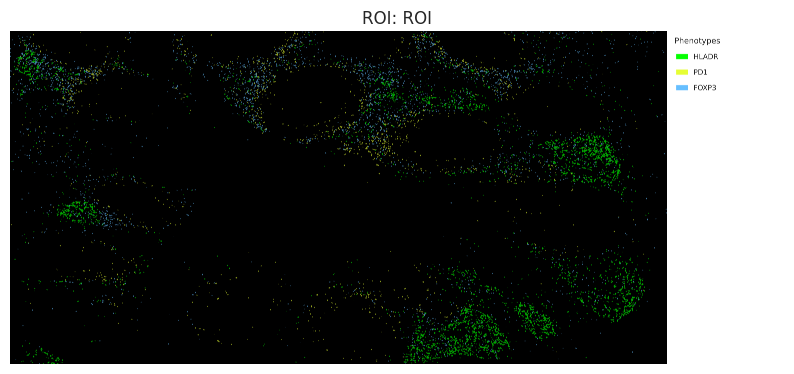

In [157]:

for roi in np.unique(df_pheno["ROI"]):
    final_img = draw_cells_for_roi(
    df_roi=df_pheno[df_pheno["ROI"] == roi],
    roi=roi,
    path_img=path_img_raw,
    path_mask=path_mask_cell,
    custom_colors=dico_color,
    output_dir=path_subpop_pheno,
)


### 📊 **Heatmap of Phenotype**
*Heatmap showing marker expression within subpopulations*


#### 🛠️ Functions

In [161]:
def heatmap_histo(df, name_value, title, path, threshold, vmin, vmax):

    sns.set(font_scale=1)

    # --- Data ---
    data = df.groupby(name_value).mean()
    counts = df[name_value].value_counts().sort_index()

    linkage_result = linkage(data, method="ward")
    order = leaves_list(linkage_result)
    data = data.iloc[order]
    counts = counts.iloc[order]

    n_clusters = len(data)
    fig = plt.figure(figsize=(10, max(6, n_clusters * 0.4)))
    fig.patch.set_facecolor('white')
    gs = GridSpec(nrows=1, ncols=2, width_ratios=[1.2, 5], wspace=0.02)

    # --- Histogram ---
    ax_bar = fig.add_subplot(gs[0])
    y_positions = [i + 0.5 for i in range(n_clusters)]

    bars = ax_bar.barh(
        y=y_positions,
        width=counts.values,
        height=1,
        color='gray'
    )

    # Add cell counts inside the histogram
    for y, count in zip(y_positions, counts.values):
        ax_bar.text(
            count - 1,
            y,
            str(count),
            va='center',
            ha='right',
            fontsize=8
        )

    ax_bar.set_yticks([])
    ax_bar.invert_xaxis()
    ax_bar.set_xlabel("")
    ax_bar.set_xticks([])
    ax_bar.xaxis.set_label_position('top')
    ax_bar.set_facecolor('none')
    ax_bar.yaxis.set_ticks_position('none')

    for spine in ['top', 'right', 'bottom']:
        ax_bar.spines[spine].set_visible(False)

    # --- Heatmap (without colorbar) ---
    ax_heatmap = fig.add_subplot(gs[1])
    heatmap = sns.heatmap(
        data,
        ax=ax_heatmap,
        vmin=vmin,
        vmax=vmax,
        cmap="vlag",
        linewidths=0.5,
        linecolor='gray',
        xticklabels=True,
        yticklabels=False,
        cbar=False   # cbar created separately
    )

    # Y-axis ticks on the right side
    ax_heatmap.set_yticks([i + 0.5 for i in range(n_clusters)])
    ax_heatmap.set_yticklabels(data.index, fontsize=12)
    ax_heatmap.yaxis.tick_right()
    ax_heatmap.yaxis.set_label_position("right")

    # Align histogram and heatmap vertically
    ax_bar.set_ylim(ax_heatmap.get_ylim())

    # --- Red box highlighting values above threshold ---
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data.iloc[i, j]
            if value > threshold:
                rect = Rectangle((j, i), 1, 1, linewidth=2,
                                 edgecolor='red', facecolor='none')
                ax_heatmap.add_patch(rect)

    # --- Main title ---
    fig.suptitle(title, fontsize=16, y=1.05)

    # --- Colorbar placed above the heatmap ---
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.cm as cm

    norm = plt.Normalize(vmin=data.values.min(), vmax=data.values.max())
    sm = plt.cm.ScalarMappable(cmap="vlag", norm=norm)
    sm.set_array([])

    # Custom position: [left, bottom, width, height]
    cax = fig.add_axes([0.13, 0.94, 0.3, 0.015])
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=8)

    # --- Save ---
    plt.tight_layout(rect=[0, 0, 1, 0.93])  # leave space for title and colorbar
    plt.savefig(path + f"Heatmap_{name_value}.png", bbox_inches='tight')
    print(f"✅ The dataframe with the {pheno} subpopulations can be found in the following folder:{path}Heatmap_{name_value}.png")
    plt.show()


#### ⚙️ Execution

/tmp/ipython-input-1151416746.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])  # leave space for title and colorbar


✅ The dataframe with the LT4 subpopulations can be found in the following folder:/content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/Heatmap_phenotype.png


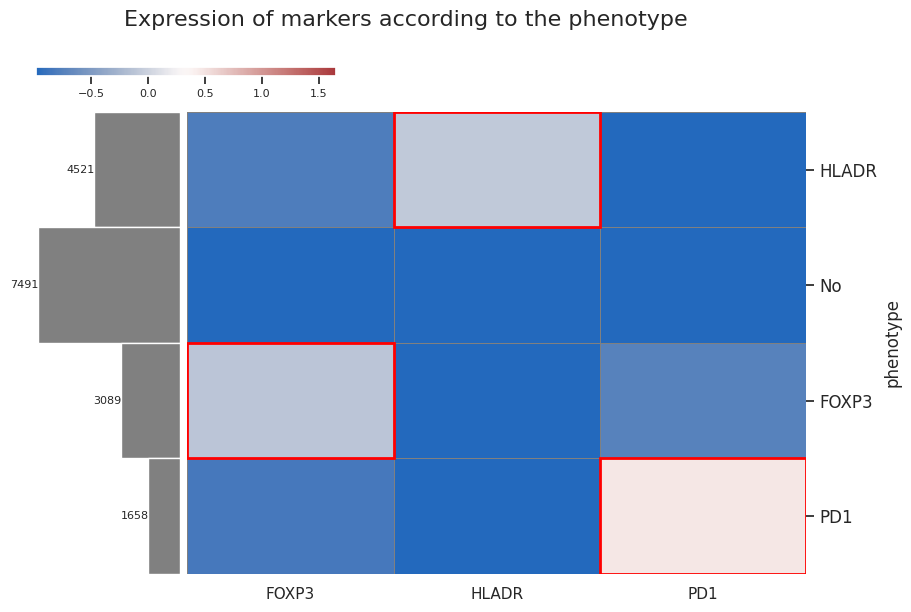

In [162]:
df_pheno=pd.read_csv(path_subpop+"df_"+pheno+"_subpopulations.csv")
df_pheno = df_pheno.drop([ "ROI", "label","Unnamed: 0","cluster"], axis=1)

heatmap_histo(df_pheno,"phenotype","Expression of markers according to the phenotype",path_subpop,threshold=0.5,vmin=0,vmax=3)


### 📊 **MFI of the markers in the phenotype**
*Graph showing the distribution of mfi for each marker within the different subpopulations*

#### Functions

In [171]:
def plot_mfi_pheno(df_mfi,path):

  list_pheno=np.unique(df_mfi["phenotype"])
  for pheno in list_pheno:
     print("pheno: "+str(pheno))
     list_data=[]
     list_marker=sorted(df_mfi.columns[:-1])
     for m in list_marker:
       list_mfi=list(df_mfi.loc[df_mfi.loc[:,"phenotype"]==pheno][m])
       list_data.append(list_mfi)
     list_col=[]
     for i in range(len(list_data)):
        if np.mean(list_data[i])>1.5:
          list_col.append("red")
        else:
          list_col.append("blue")

     pos=[float(p) for p in range(0,len(list_data))]
     fig,ax = plt.subplots(1,1,figsize=(70,10))
     violin=plt.violinplot(list_data,pos,showextrema=False,showmedians=True)
     c=0
     for pc in violin['bodies']:
       pc.set_facecolor(list_col[c])
       c+=1
     ax.set_title("Phenotype: "+pheno+": "+str(df_mfi.loc[df_mfi.loc[:,"phenotype"]==pheno].shape[0]),fontsize=40)
     plt.ylabel("Z-score",size=30)
     ax.set_xticks(np.arange(0,len(list_marker)),list_marker,size=25)
     plt.savefig(path+str(pheno)+".png")


#### Execution

In [172]:
path_plot_mfi_pheno=path_subpop+"plot_mfi_pheno/"
if os.path.isdir(path_plot_mfi_pheno)==False:
  os.mkdir(path_plot_mfi_pheno)

In [173]:
df_subpop_pheno=pd.read_csv(path_subpop+"df_"+pheno+"_subpopulations.csv")
df_subpop_pheno = df_subpop_pheno.drop(["label", "ROI","Unnamed: 0","cluster"], axis=1)
df_subpop_pheno.head()

,FOXP3,HLADR,PD1,phenotype
0,2.138132,3.062035,1.497794,HLADR
1,-0.378150,-0.685014,2.432714,PD1
2,-0.287683,-1.348972,-0.240394,No
3,0.068727,-0.936490,0.409420,No
4,0.441679,-0.485195,0.128908,FOXP3


pheno: FOXP3
pheno: HLADR
pheno: No
pheno: PD1


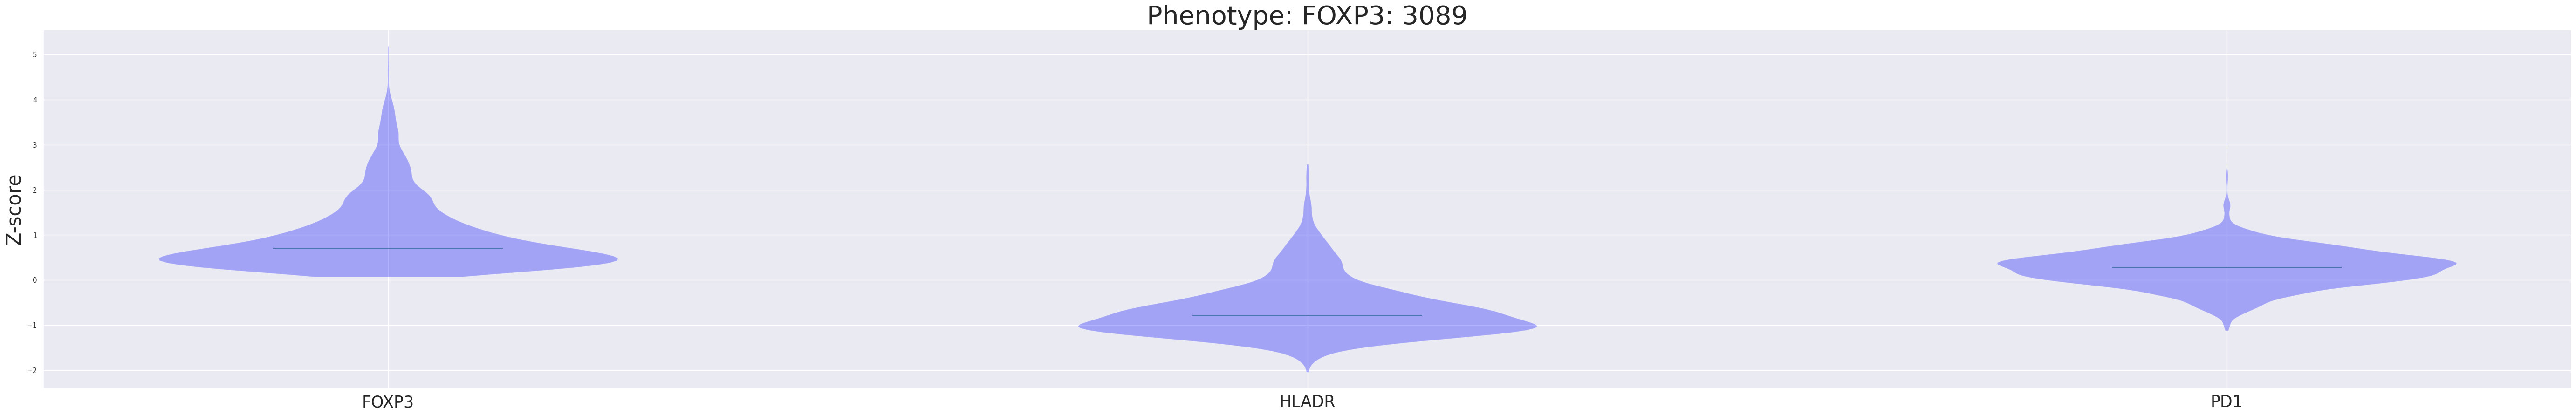

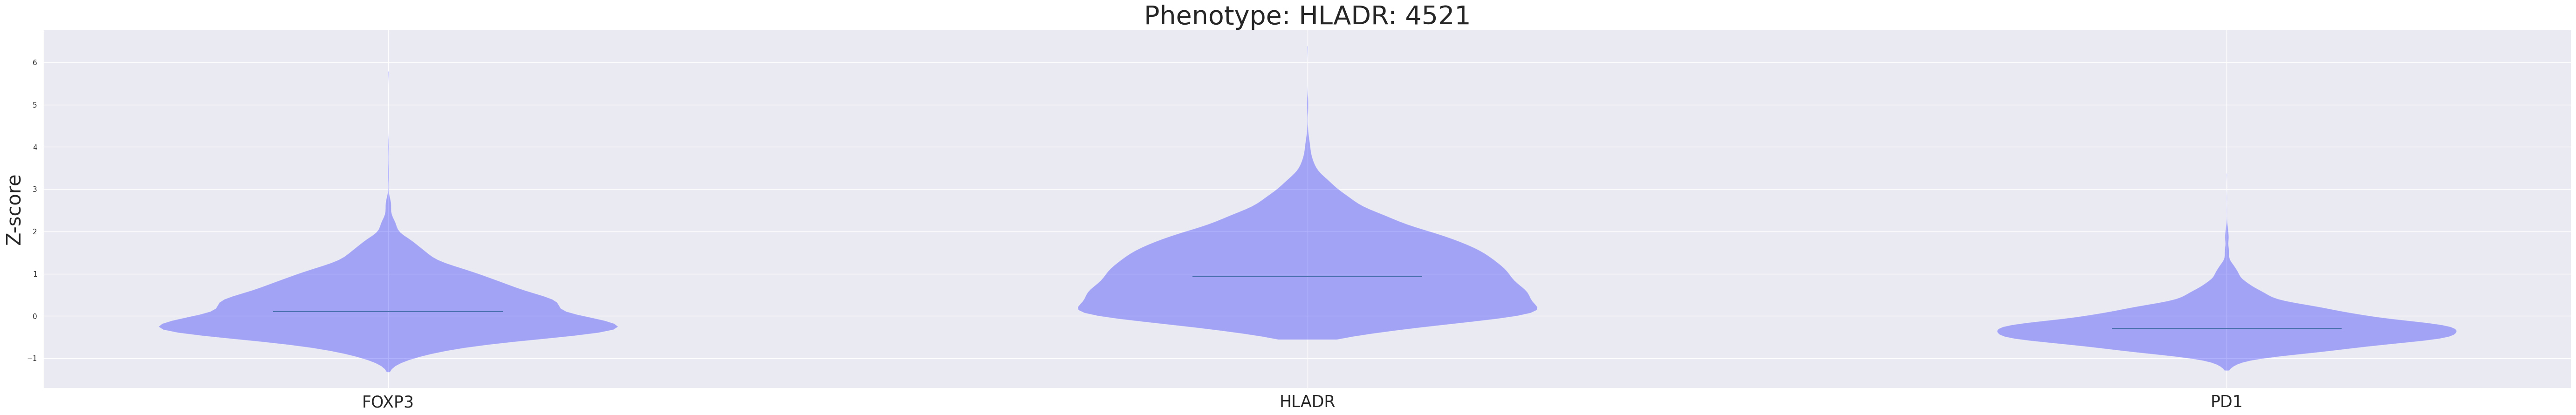

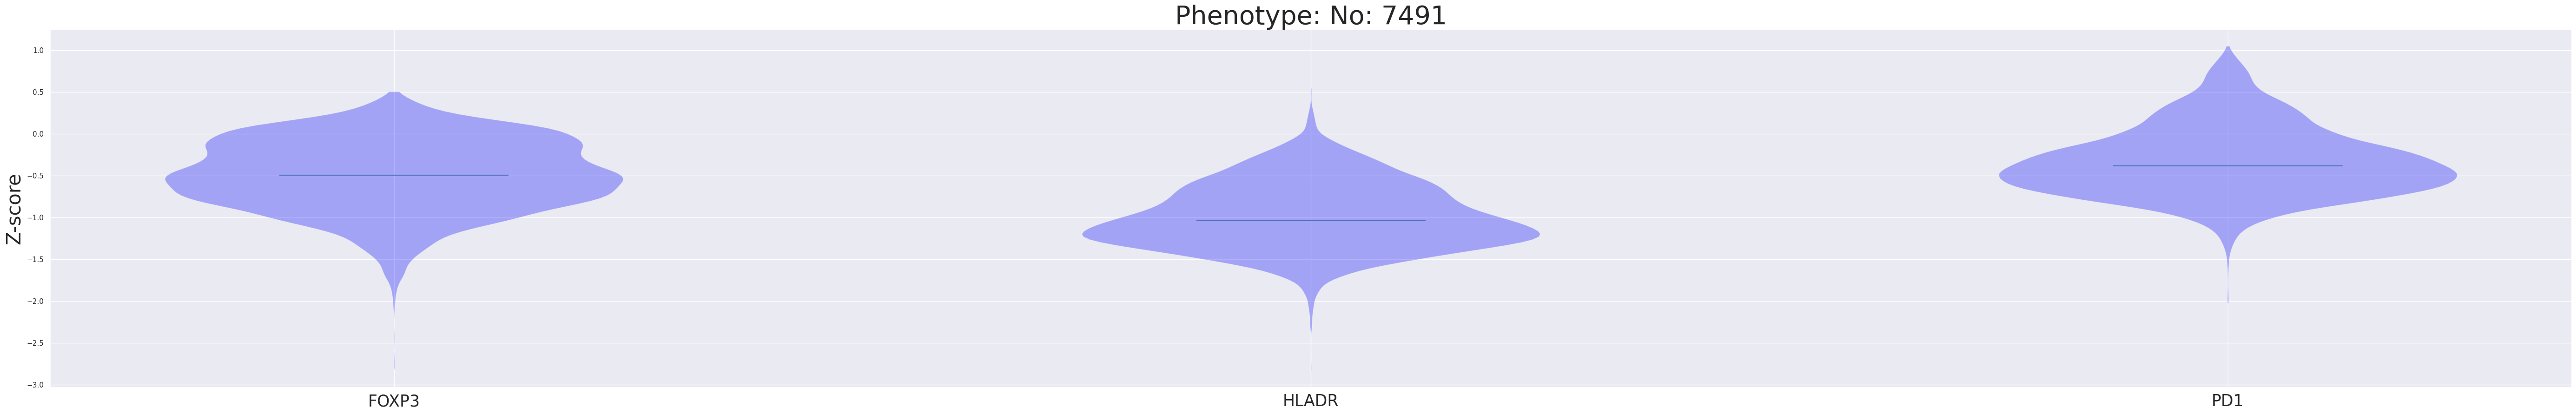

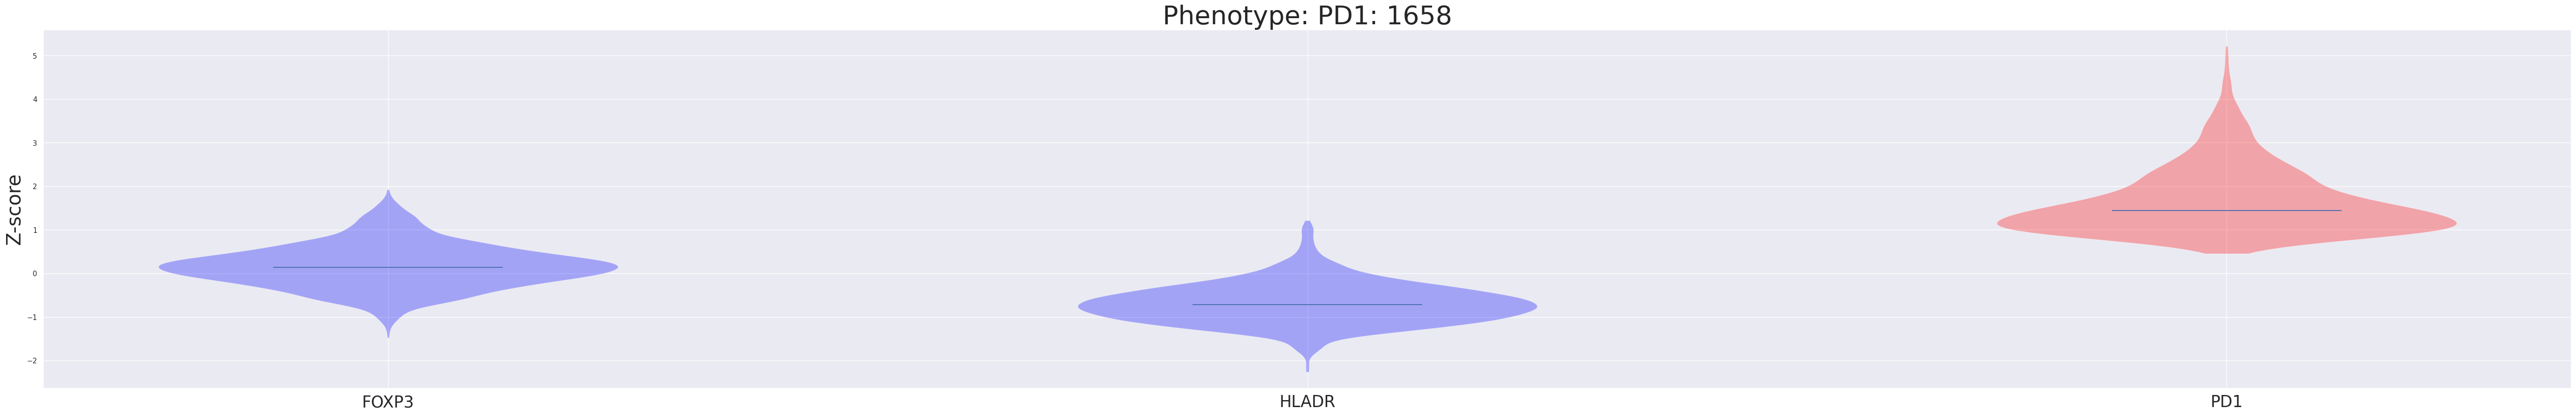

In [174]:
plot_mfi_pheno(df_subpop_pheno,path_plot_mfi_pheno)

### 📊 **Outline the phenotypes**
⚠️ USER INPUT REQUIRED  
*To assess the quality of the phenotype annotation, this cell creates images for each phenotype, including the appropriate markers and an image with the outlines of the cells belonging to that phenotype.*

#### 🛠️ Functions

In [163]:
import os
import numpy as np
import cv2
from PIL import Image
from tqdm.auto import tqdm
from skimage.segmentation import find_boundaries

# ---------- IO ----------
def read_gray(path):
    arr = np.array(Image.open(path))
    if arr.ndim > 2:
        arr = arr[..., 0]
    return arr.astype(np.float32)

# ---------- Normalisation robuste (anti-voile gris) ----------
def normalize_robust_uint8(arr, p_low=1.0, p_high=99.8, gamma=1.0):
    """
    Clip percentiles + rescale 0..255 + gamma.
    Très supérieur au min-max sur grandes images.
    """
    if arr is None:
        return None
    lo, hi = np.percentile(arr, [p_low, p_high])
    if hi <= lo:
        out = np.zeros_like(arr, dtype=np.uint8)
        return out

    x = np.clip(arr, lo, hi)
    x = (x - lo) / (hi - lo)

    if gamma != 1.0:
        x = np.power(x, gamma)

    return (x * 255).astype(np.uint8)

# ---------- Marqueurs : sum / mean / max ----------
def load_and_combine_markers(roi, markers, path_img_raw, combine="max"):
    imgs = []
    for m in markers:
        # essaye tif/tiff/png
        for ext in (".tif", ".tiff", ".png", ".jpg", ".jpeg"):
            p = os.path.join(path_img_raw, roi, f"{m}{ext}")
            if os.path.isfile(p):
                imgs.append(read_gray(p))
                break

    if not imgs:
        return None

    stack = np.stack(imgs, axis=0)

    if combine == "sum":
        out = np.sum(stack, axis=0)
    elif combine == "mean":
        out = np.mean(stack, axis=0)
    elif combine == "max":
        out = np.max(stack, axis=0)
    else:
        raise ValueError("combine must be one of: 'sum', 'mean', 'max'")

    # Option : arcsinh, mais moins agressif que *10
    out = np.arcsinh(out * 3.0)

    return out

# ---------- Contours complets pour un sous-ensemble de labels ----------
def boundaries_for_labels(mask, labels, mode="outer", thickness=2):
    """
    Important: on met à 0 les labels non sélectionnés,
    puis find_boundaries sur ce label-image => contours complets.
    """
    labels = np.asarray(list(labels), dtype=np.int64)
    sel = np.isin(mask, labels)

    # label image "restreinte" : conserve les IDs pour les cellules sélectionnées, sinon 0
    mask_sel = np.where(sel, mask, 0).astype(np.int64)

    # frontières complètes (outer donne des contours plus "fermés")
    b = find_boundaries(mask_sel, mode=mode)  # bool

    if thickness > 1:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*thickness+1, 2*thickness+1))
        b = cv2.dilate((b.astype(np.uint8) * 255), k) > 0

    return b

# ---------- Pipeline ROI x phenotype ----------
def generate_pheno_outline_images(
    df_pheno,
    dico_pheno_marker,
    path_img_raw,
    path_mask,
    output_dir,
    contour_colors=None,         # dict pheno -> (R,G,B) optionnel
    default_contour_color=(255, 255, 0),
    contour_thickness=2,
    combine_markers="max",       # 'max' recommandé pour éviter surexposition
    p_low=1.0,
    p_high=99.8,
    gamma=0.9,
    boundary_mode="outer"
):
    os.makedirs(output_dir, exist_ok=True)

    rois = df_pheno["ROI"].unique()

    for roi in tqdm(rois, desc="ROIs"):
        # masque
        mask_path = None
        for ext in (".tif", ".tiff", ".png"):
            p = os.path.join(path_mask, f"{roi}{ext}")
            if os.path.isfile(p):
                mask_path = p
                break
        if mask_path is None:
            continue

        mask = np.array(Image.open(mask_path))
        if mask.ndim > 2:
            mask = mask[..., 0]
        mask = mask.astype(np.int64)

        df_roi = df_pheno[df_pheno["ROI"] == roi]

        for pheno, markers in dico_pheno_marker.items():
            df_p = df_roi[df_roi["phenotype"] == pheno]
            if df_p.empty:
                continue

            # image marqueurs (max/sum/mean)
            img = load_and_combine_markers(roi, markers, path_img_raw, combine=combine_markers)
            if img is None:
                continue

            # normalisation robuste -> supprime le voile gris
            img8 = normalize_robust_uint8(img, p_low=p_low, p_high=p_high, gamma=gamma)
            img_rgb = np.dstack([img8]*3)

            # labels du phénotype
            labels = set(df_p["label"].astype(int).values)

            # contours complets (corrige votre problème)
            b = boundaries_for_labels(mask, labels, mode=boundary_mode, thickness=contour_thickness)

            # couleur contour
            if contour_colors and pheno in contour_colors:
                color = contour_colors[pheno]
            else:
                color = default_contour_color

            img_rgb[b] = color

            # save
            out_dir = os.path.join(output_dir, pheno)
            os.makedirs(out_dir, exist_ok=True)
            out_path = os.path.join(out_dir, f"{roi}.png")
            Image.fromarray(img_rgb).save(out_path)

    print(f"✅ Images générées dans: {output_dir}")


In [164]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def build_dico_pheno_marker_interactive(list_pheno, list_marker, title="Phenotype → marker selection"):
    # Nettoyage
    list_pheno = [p.strip() for p in list_pheno if str(p).strip()]
    list_marker = [m.strip() for m in list_marker if str(m).strip()]

    state = {"i": 0, "dico": {}}

    pheno_lbl = widgets.HTML()
    marker_sel = widgets.SelectMultiple(
        options=list_marker,
        description="Markers",
        rows=min(12, len(list_marker)),
        layout=widgets.Layout(width="460px", height="220px")
    )

    btn_save_next = widgets.Button(description="✅ Save & Next", button_style="success")
    btn_skip = widgets.Button(description="⏭ Skip", button_style="")
    btn_finish = widgets.Button(description="🏁 Finish", button_style="info")

    out = widgets.Output()

    def render():
        clear_output(wait=True)

        if state["i"] >= len(list_pheno):
            display(widgets.HTML("<h3 style='color:#2ca02c'>✔ Selection finished</h3>"))
            display(out)
            with out:
                out.clear_output(wait=True)
                print("dico_pheno_marker =")
                print(state["dico"])
            return

        ph = list_pheno[state["i"]]
        pheno_lbl.value = f"<h3 style='color:#1976d2'>🧬 Phenotype: {ph}</h3>"

        # pré-remplir si déjà défini
        marker_sel.value = tuple(state["dico"].get(ph, []))

        display(widgets.HTML(f"<h2 style='color:#1976d2'>{title}</h2>"))
        display(pheno_lbl)
        display(widgets.HTML("<b>Select the markers associated with this phenotype:</b>"))
        display(marker_sel)
        display(widgets.HBox([btn_save_next, btn_skip, btn_finish]))
        display(out)

        with out:
            out.clear_output(wait=True)
            done = sum(1 for p in list_pheno if p in state["dico"])
            print(f"Progress: {done}/{len(list_pheno)} phenotypes completed.")

    def on_save_next(_):
        ph = list_pheno[state["i"]]
        state["dico"][ph] = list(marker_sel.value)
        state["i"] += 1
        render()

    def on_skip(_):
        ph = list_pheno[state["i"]]
        state["dico"][ph] = []
        state["i"] += 1
        render()

    def on_finish(_):
        # sauvegarde le phénotype en cours avant de terminer
        if state["i"] < len(list_pheno):
            ph = list_pheno[state["i"]]
            state["dico"][ph] = list(marker_sel.value)
        state["i"] = len(list_pheno)
        render()

    btn_save_next.on_click(on_save_next)
    btn_skip.on_click(on_skip)
    btn_finish.on_click(on_finish)

    render()
    return state  # state["dico"] contient le dictionnaire final


#### ⚙️ Execution

In [166]:
df_pheno=pd.read_csv(path_subpop+"df_"+pheno+"_subpopulations.csv")
df_num=df_pheno.drop(["ROI","label","cluster","phenotype","Unnamed: 0"],axis=1)

df_num.head()

,FOXP3,HLADR,PD1
0,2.138132,3.062035,1.497794
1,-0.378150,-0.685014,2.432714
2,-0.287683,-1.348972,-0.240394
3,0.068727,-0.936490,0.409420
4,0.441679,-0.485195,0.128908


In [167]:
# Exemples
list_pheno = np.unique(df_pheno["phenotype"])
list_marker = np.unique(df_num.columns)

state = build_dico_pheno_marker_interactive(list_pheno, list_marker)

# Après sélection (et Finish), récupérez :
dico_pheno_marker = state["dico"]


HTML(value="<h3 style='color:#2ca02c'>✔ Selection finished</h3>")

Output()

In [168]:
path_check_pheno=path_subpop+"check_pheno_outline/"
if os.path.isdir(path_check_pheno)==False:
  os.mkdir(path_check_pheno)
path_processing=path+"images/img_processing_1/Biopsies/"

In [169]:
generate_pheno_outline_images(
    df_pheno=df_pheno,
    dico_pheno_marker=dico_pheno_marker,
    path_img_raw=path_img_raw,
    path_mask=path_mask_cell,
    output_dir=path_check_pheno,
    combine_markers="max",
    p_low=5.0, p_high=99.8, gamma=0.9,
    contour_thickness=1,
    boundary_mode="outer"
)


ROIs:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


✅ Images générées dans: /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/check_pheno_outline/


### 📊 **Visualization of the ouline of the objects belonging to a phenotype on images withthe appropriate markers from biopsies samples**
⚠️ USER INPUT REQUIRED  
*To assess the quality of phenotype annotation, this cell creates images for each phenotype, including the appropriate markers and an image with the outlines of the cells belonging to that phenotype, on biopsy samples whose size and number can be chosen.*

#### Function

In [175]:
# ======================================================
# ROI x phenotype: create N random (or informative) samples
# Left  : markers-only patch
# Right : same patch + complete cell contours for selected phenotype labels
# + a small spacer between left/right for readability
# ======================================================

import os
import numpy as np
import cv2
from PIL import Image
from tqdm.auto import tqdm
from skimage.segmentation import find_boundaries

# -----------------------------
# I/O
# -----------------------------
SUPPORTED_IMG_EXT = (".tif", ".tiff", ".png", ".jpg", ".jpeg")
SUPPORTED_MASK_EXT = (".tif", ".tiff", ".png")

def read_gray(path):
    """Read image as float32 grayscale."""
    arr = np.array(Image.open(path))
    if arr.ndim > 2:
        arr = arr[..., 0]
    return arr.astype(np.float32)

def find_first_existing(path_no_ext):
    """Try supported extensions for a path without extension and return the first existing path, else None."""
    for ext in SUPPORTED_IMG_EXT:
        p = path_no_ext + ext
        if os.path.isfile(p):
            return p
    return None

def find_mask_path(path_mask, roi):
    """Find ROI mask file in path_mask with supported extensions."""
    for ext in SUPPORTED_MASK_EXT:
        p = os.path.join(path_mask, f"{roi}{ext}")
        if os.path.isfile(p):
            return p
    return None

# -----------------------------
# Robust normalization (anti gray veil)
# -----------------------------
def normalize_robust_uint8(arr, p_low=1.0, p_high=99.8, gamma=1.0, eps=1e-8):
    """
    Percentile clip + rescale to uint8 + gamma correction.
    Works well on large biopsies (prevents "gray haze").
    """
    if arr is None:
        return None
    lo, hi = np.percentile(arr, [p_low, p_high])
    if hi <= lo + eps:
        return np.zeros_like(arr, dtype=np.uint8)

    x = np.clip(arr, lo, hi)
    x = (x - lo) / (hi - lo)

    if gamma != 1.0:
        x = np.power(x, gamma)

    return (x * 255).astype(np.uint8)

# -----------------------------
# Marker combine (sum/mean/max)
# -----------------------------
def load_and_combine_markers(roi, markers, path_img_raw, combine="max", arcsinh_scale=3.0):
    """
    Load several marker images for a ROI and combine them into one grayscale image.
    combine: 'max' (recommended), 'mean', or 'sum'
    arcsinh_scale: scaling inside arcsinh to control contrast.
    """
    imgs = []
    for m in markers:
        p = find_first_existing(os.path.join(path_img_raw, roi, m))
        if p is None:
            continue
        imgs.append(read_gray(p))

    if not imgs:
        return None

    stack = np.stack(imgs, axis=0)

    if combine == "sum":
        out = np.sum(stack, axis=0)
    elif combine == "mean":
        out = np.mean(stack, axis=0)
    elif combine == "max":
        out = np.max(stack, axis=0)
    else:
        raise ValueError("combine must be one of: 'sum', 'mean', 'max'")

    # Gentle transform to reduce outlier dominance
    out = np.arcsinh(out * float(arcsinh_scale))
    return out

# -----------------------------
# Complete boundaries for subset of labels
# -----------------------------
def boundaries_for_labels(mask, labels, mode="outer", thickness=2):
    """
    Keep only selected labels in the mask, then compute boundaries => complete contours.
    mode: 'outer' recommended for closed-ish boundaries.
    thickness: dilation thickness (>=1)
    """
    labels = np.asarray(list(labels), dtype=np.int64)
    if labels.size == 0:
        return np.zeros(mask.shape, dtype=bool)

    sel = np.isin(mask, labels)
    mask_sel = np.where(sel, mask, 0).astype(np.int64)

    b = find_boundaries(mask_sel, mode=mode)  # bool

    if thickness > 1:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * thickness + 1, 2 * thickness + 1))
        b = cv2.dilate((b.astype(np.uint8) * 255), k) > 0

    return b

# -----------------------------
# Patch sampling
# -----------------------------
def sample_patch_coords(H, W, patch_size, n_samples, rng):
    """
    Returns list of (y0, y1, x0, x1) boxes within bounds.
    """
    ps = int(patch_size)
    if ps <= 0:
        raise ValueError("patch_size must be > 0")

    if ps > H or ps > W:
        ps = min(H, W)

    coords = []
    for _ in range(n_samples):
        y0 = int(rng.integers(0, max(1, H - ps + 1)))
        x0 = int(rng.integers(0, max(1, W - ps + 1)))
        coords.append((y0, y0 + ps, x0, x0 + ps))
    return coords

# -----------------------------
# Main pipeline
# -----------------------------
def generate_pheno_outline_samples_side_by_side(
    df_pheno,
    dico_pheno_marker,
    path_img_raw,
    path_mask,
    output_dir,
    n_samples=5,
    patch_size=512,
    seed=0,
    contour_colors=None,          # dict pheno -> (R,G,B) optional
    default_contour_color=(255, 255, 0),
    contour_thickness=2,
    combine_markers="max",
    arcsinh_scale=3.0,
    p_low=1.0,
    p_high=99.8,
    gamma=0.9,
    boundary_mode="outer",
    only_informative=True,        # try to pick patches containing contours
    min_boundary_pixels=50,
    spacer_width=20,              # space between left/right
    spacer_color=255              # 255=white, 0=black
):
    """
    Creates for each ROI and phenotype:
      - N patch samples
      - side-by-side image: left markers-only, right markers+contours
      - adds a spacer between the two images
    Output structure:
      output_dir/<phenotype>/<ROI>__sampleK_yY_xX.png
    """
    os.makedirs(output_dir, exist_ok=True)
    rng = np.random.default_rng(seed)

    # safety checks
    required_cols = {"ROI", "phenotype", "label"}
    missing_cols = required_cols - set(df_pheno.columns)
    if missing_cols:
        raise ValueError(f"df_pheno missing required columns: {missing_cols}")

    rois = df_pheno["ROI"].dropna().unique()

    for roi in tqdm(rois, desc="ROIs"):
        mask_path_roi = find_mask_path(path_mask, roi)
        if mask_path_roi is None:
            continue

        # Load mask
        mask = np.array(Image.open(mask_path_roi))
        if mask.ndim > 2:
            mask = mask[..., 0]
        mask = mask.astype(np.int64)
        H, W = mask.shape[:2]

        df_roi = df_pheno[df_pheno["ROI"] == roi]

        for pheno, markers in dico_pheno_marker.items():
            df_p = df_roi[df_roi["phenotype"] == pheno]
            if df_p.empty:
                continue

            labels = set(df_p["label"].astype(int).values)
            if len(labels) == 0:
                continue

            # Load & combine markers once for this (ROI, phenotype)
            img_full = load_and_combine_markers(
                roi=roi,
                markers=markers,
                path_img_raw=path_img_raw,
                combine=combine_markers,
                arcsinh_scale=arcsinh_scale
            )
            if img_full is None:
                continue

            # Robust normalization to uint8
            img8_full = normalize_robust_uint8(img_full, p_low=p_low, p_high=p_high, gamma=gamma)
            img_rgb_full = np.dstack([img8_full] * 3).astype(np.uint8)

            # Compute boundaries once
            b_full = boundaries_for_labels(mask, labels, mode=boundary_mode, thickness=contour_thickness)

            # Choose contour color
            if contour_colors and pheno in contour_colors:
                color = contour_colors[pheno]
            else:
                color = default_contour_color

            # Sample patches
            if only_informative:
                coords = []
                candidates = sample_patch_coords(H, W, patch_size, n_samples * 10, rng)
                for (y0, y1, x0, x1) in candidates:
                    if int(b_full[y0:y1, x0:x1].sum()) >= int(min_boundary_pixels):
                        coords.append((y0, y1, x0, x1))
                    if len(coords) >= n_samples:
                        break
                if len(coords) < n_samples:
                    coords += sample_patch_coords(H, W, patch_size, n_samples - len(coords), rng)
            else:
                coords = sample_patch_coords(H, W, patch_size, n_samples, rng)

            # Output folder per phenotype
            out_dir_ph = os.path.join(output_dir, pheno)
            os.makedirs(out_dir_ph, exist_ok=True)

            for k, (y0, y1, x0, x1) in enumerate(coords, start=1):
                left = img_rgb_full[y0:y1, x0:x1].copy()

                right = left.copy()
                b_patch = b_full[y0:y1, x0:x1]
                right[b_patch] = color

                # spacer between left and right
                spacer = np.full((left.shape[0], int(spacer_width), 3), int(spacer_color), dtype=np.uint8)

                # side-by-side with spacer
                side = np.concatenate([left, spacer, right], axis=1)

                out_path = os.path.join(out_dir_ph, f"{roi}__sample{k}_y{y0}_x{x0}.png")
                Image.fromarray(side).save(out_path)

    print(f"✅ Samples generated in: {output_dir}")


# ======================================================
# Example usage:
# n_samples = int(input("Number of samples per ROI? (e.g., 5): "))
# patch_size = int(input("Patch size (px)? (e.g., 512 or 1024): "))
#
# generate_pheno_outline_samples_side_by_side(
#     df_pheno=df_pheno,
#     dico_pheno_marker=dico_pheno_marker,
#     path_img_raw=path_img_raw,
#     path_mask=path_mask_cell,
#     output_dir=path_output_samples,
#     n_samples=n_samples,
#     patch_size=patch_size,
#     spacer_width=25,
#     spacer_color=255
# )
# ======================================================


In [176]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def build_dico_pheno_marker_interactive(list_pheno, list_marker, title="Phenotype → marker selection"):
    # Nettoyage
    list_pheno = [p.strip() for p in list_pheno if str(p).strip()]
    list_marker = [m.strip() for m in list_marker if str(m).strip()]

    state = {"i": 0, "dico": {}}

    pheno_lbl = widgets.HTML()
    marker_sel = widgets.SelectMultiple(
        options=list_marker,
        description="Markers",
        rows=min(12, len(list_marker)),
        layout=widgets.Layout(width="460px", height="220px")
    )

    btn_save_next = widgets.Button(description="✅ Save & Next", button_style="success")
    btn_skip = widgets.Button(description="⏭ Skip", button_style="")
    btn_finish = widgets.Button(description="🏁 Finish", button_style="info")

    out = widgets.Output()

    def render():
        clear_output(wait=True)

        if state["i"] >= len(list_pheno):
            display(widgets.HTML("<h3 style='color:#2ca02c'>✔ Selection finished</h3>"))
            display(out)
            with out:
                out.clear_output(wait=True)
                print("dico_pheno_marker =")
                print(state["dico"])
            return

        ph = list_pheno[state["i"]]
        pheno_lbl.value = f"<h3 style='color:#1976d2'>🧬 Phenotype: {ph}</h3>"

        # pré-remplir si déjà défini
        marker_sel.value = tuple(state["dico"].get(ph, []))

        display(widgets.HTML(f"<h2 style='color:#1976d2'>{title}</h2>"))
        display(pheno_lbl)
        display(widgets.HTML("<b>Select the markers associated with this phenotype:</b>"))
        display(marker_sel)
        display(widgets.HBox([btn_save_next, btn_skip, btn_finish]))
        display(out)

        with out:
            out.clear_output(wait=True)
            done = sum(1 for p in list_pheno if p in state["dico"])
            print(f"Progress: {done}/{len(list_pheno)} phenotypes completed.")

    def on_save_next(_):
        ph = list_pheno[state["i"]]
        state["dico"][ph] = list(marker_sel.value)
        state["i"] += 1
        render()

    def on_skip(_):
        ph = list_pheno[state["i"]]
        state["dico"][ph] = []
        state["i"] += 1
        render()

    def on_finish(_):
        # sauvegarde le phénotype en cours avant de terminer
        if state["i"] < len(list_pheno):
            ph = list_pheno[state["i"]]
            state["dico"][ph] = list(marker_sel.value)
        state["i"] = len(list_pheno)
        render()

    btn_save_next.on_click(on_save_next)
    btn_skip.on_click(on_skip)
    btn_finish.on_click(on_finish)

    render()
    return state  # state["dico"] contient le dictionnaire final


#### Execution

In [177]:
df_pheno=pd.read_csv(path_subpop+"df_"+pheno+"_subpopulations.csv")
df_num=df_pheno.drop(["ROI","label","cluster","phenotype","Unnamed: 0"],axis=1)

df_num.head()

,FOXP3,HLADR,PD1
0,2.138132,3.062035,1.497794
1,-0.378150,-0.685014,2.432714
2,-0.287683,-1.348972,-0.240394
3,0.068727,-0.936490,0.409420
4,0.441679,-0.485195,0.128908


In [178]:
path_check_pheno=path_subpop+"check_pheno_outline_crop/"
if os.path.isdir(path_check_pheno)==False:
  os.mkdir(path_check_pheno)
path_processing=path+"images/img_processing_1/Biopsies/"

In [179]:
list_pheno = np.unique(df_pheno["phenotype"])
list_marker = np.unique(df_num.columns)

state = build_dico_pheno_marker_interactive(list_pheno, list_marker)
dico_pheno_marker = state["dico"]


HTML(value="<h3 style='color:#2ca02c'>✔ Selection finished</h3>")

Output()

In [181]:
n_samples = int(input("Number of samples per biopsy ? (ex: 5) : "))
patch_size = int(input("Size of the samples (pixels) ? (ex: 512 ou 1024) : "))

generate_pheno_outline_samples_side_by_side(
    df_pheno=df_pheno,
    dico_pheno_marker=dico_pheno_marker,
    path_img_raw=path_img_raw,
    path_mask=path_mask_cell,
    output_dir=path_check_pheno,
    n_samples=n_samples,
    patch_size=patch_size,
    contour_colors=None,
    contour_thickness=1,
    combine_markers="max",
    gamma=0.9,
    only_informative=True
)


Number of samples per biopsy ? (ex: 5) : 5
Size of the samples (pixels) ? (ex: 512 ou 1024) : 150


ROIs:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119362188 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


✅ Samples generated in: /content/gdrive/MyDrive/these/pipeline/Appendix/clustering/LT4/check_pheno_outline_crop/
